# 📦 Procurement Analytics: SARIMA Time-Series Forecasting
---

*Model:* SARIMA (Seasonal AutoRegressive Integrated Moving Average)  
*SDG:* SDG 8: Decent Work and Economic Growth
       SDG 9: Industry, Innovation and Infrastructure
       SDG 12: Responsible Consumption and Production  
*Dataset:* Enterprise Procurement Orders (2022–2023)
https://www.kaggle.com/datasets/shahriarkabir/procurement-kpi-analysis-dataset

---

# **I. Business / Problem Understanding**

## **Analytical Objective**

Organizations depend on procurement and supplier management to ensure that materials and products are delivered on time, meet quality standards, and remain within budget. However, suppliers differ significantly in their performance. Some consistently deliver high-quality goods on schedule, while others experience delays, defects, and cost inefficiencies. When procurement teams manage hundreds of suppliers, it becomes difficult to manually identify meaningful patterns in supplier behavior.

The objective of this analysis is to apply Clustering (Unsupervised Learning) techniques to segment suppliers into distinct groups based on key procurement performance indicators. These indicators may include procurement cost, lead time, delivery delay, defect rate, quantity ordered, and supplier performance scores.

By analyzing these variables, the clustering model will uncover hidden patterns and naturally occurring supplier segments without relying on predefined labels. The resulting clusters will help identify suppliers that are strategic and reliable, those that are cost-efficient, and those that present operational risks due to poor delivery and quality performance.

## **Intended End Users**

The results of this clustering analysis are designed to support several stakeholders within the organization:

* **Procurement Managers** - to evaluate supplier performance and improve sourcing strategies.
* **Supply Chain Analysts** – to monitor operational risks and supplier trends.
* **Operations Managers** – to ensure continuity of materials and products.
* **Executive Decision Makers** – to guide strategic procurement and budgeting decisions.

## **Business Value of Clustering**

Supplier segmentation provides procurement managers with a data-driven approach to understanding supplier behavior. Rather than evaluating suppliers individually, clustering allows organizations to group suppliers with similar characteristics and performance profiles.

This analysis can help organizations:

Identify Strategic Suppliers that consistently deliver high-quality products on time.
Detect Cost-Efficient Suppliers that offer competitive pricing with acceptable performance.
Recognize High-Risk Suppliers associated with frequent delays, defects, or inconsistent service.
Isolate Underperforming Suppliers that may require corrective action or contract review.

These insights support better procurement decisions, including supplier selection, contract negotiations, risk mitigation, and performance monitoring. In the long run, data-driven supplier segmentation improves operational efficiency, reduces procurement costs, and strengthens supply chain resilience.

## **Sustainable Development Goals (SDGs)**

**SDG 8: Decent Work and Economic Growth**
By clustering suppliers into performance-based segments, the project helps organizations identify high-performing and high-risk suppliers, improve procurement efficiency, and strengthen supplier relationships. This data-driven segmentation supports more productive operations, reduces costly disruptions, and contributes to sustainable economic growth.

**SDG 12: Responsible Consumption and Production**
The clustering model groups suppliers according to lead time, defect rate, savings rate, and order value, enabling procurement teams to detect suppliers with quality and compliance issues. By targeting underperforming clusters and prioritizing reliable suppliers, organizations can reduce waste, improve product quality, and build more sustainable sourcing partnerships.

**SDG 9: Industry, Innovation and Infrastructure**
The application of K-Means clustering demonstrates how machine learning can modernize procurement and supply chain management. By transforming procurement data into actionable supplier segments, the project promotes innovation, strengthens operational infrastructure, and supports smarter and more resilient supply chain systems.


# **II. Data Understanding**

## **Import Required Libraries**

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patches as patches
import seaborn as sns

# Scikit-learn: clustering, preprocessing, evaluation
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from matplotlib.patches import Ellipse
from collections import defaultdict

# SciPy: hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import cdist

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Global settings
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

print("All libraries imported successfully.")

All libraries imported successfully.


The notebook begins by importing the necessary Python libraries required for data preprocessing, visualization, clustering, and evaluation. Libraries such as Pandas and NumPy were used for data manipulation and numerical computations, while Matplotlib and Seaborn were utilized for graphical visualization and exploratory data analysis.

In addition, Scikit-learn libraries were imported to support preprocessing techniques, clustering algorithms, dimensionality reduction, and evaluation metrics. These libraries provided the essential tools needed to perform procurement segmentation and analyze supplier performance using clustering methods.

## **Load Dataset**

In [ ]:
df = pd.read_csv('/content/sample_data/Procurement-KPI-Analysis-Dataset.csv')

print(f"Dataset loaded. Shape: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset loaded. Shape: 777 rows x 11 columns


The procurement dataset was successfully loaded into the notebook for analysis and clustering. The dataset contains 777 procurement transaction records and 11 variables that describe supplier information, procurement costs, delivery details, order fulfillment, and product quality indicators.

Loading the dataset is an important first step because it allows the analysis to inspect the structure, completeness, and overall quality of the procurement records before preprocessing and clustering are performed.

## **Describing the Data**

In [ ]:
print("=" * 55)
print("SHOW FIRST 5 ROWS")
print("=" * 55)
df.head()

SHOW FIRST 5 ROWS


,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance
0,PO-00001,Alpha_Inc,2023-10-17,2023-10-25,Office Supplies,Cancelled,1176,20.13,17.81,NaN,Yes
1,PO-00002,Delta_Logistics,2022-04-25,2022-05-05,Office Supplies,Delivered,1509,39.32,37.34,235.0,Yes
2,PO-00003,Gamma_Co,2022-01-26,2022-02-15,MRO,Delivered,910,95.51,92.26,41.0,Yes
3,PO-00004,Beta_Supplies,2022-10-09,2022-10-28,Packaging,Delivered,1344,99.85,95.52,112.0,Yes
4,PO-00005,Delta_Logistics,2022-09-08,2022-09-20,Raw Materials,Delivered,1180,64.07,60.53,171.0,No


Displaying the first few rows of the dataset provides an initial overview of the procurement records and their corresponding variables. This step helps verify whether the dataset was imported correctly and allows the researcher to understand the format and content of each column.

The preview shows procurement-related information such as supplier names, order status, product pricing, quantities, delivery dates, and defective units. Examining these records early in the analysis helps identify potential formatting issues and gives a clearer understanding of how the procurement data is organized.

In [ ]:
print("=" * 55)
print("SHOW LAST 5 ROWS")
print("=" * 55)
df.tail()

SHOW LAST 5 ROWS


,PO_ID,Supplier,Order_Date,Delivery_Date,Item_Category,Order_Status,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance
772,PO-00773,Delta_Logistics,2023-02-11,2023-02-20,Electronics,Delivered,1685,43.42,42.24,262.0,Yes
773,PO-00774,Alpha_Inc,2022-07-23,NaN,Office Supplies,Delivered,445,68.94,60.35,7.0,Yes
774,PO-00775,Gamma_Co,2022-03-19,2022-04-07,Raw Materials,Delivered,494,94.82,81.89,29.0,Yes
775,PO-00776,Beta_Supplies,2023-08-30,2023-09-11,MRO,Delivered,1306,21.05,18.27,128.0,Yes
776,PO-00777,Beta_Supplies,2023-12-09,2023-12-11,Office Supplies,Delivered,1988,105.20,93.23,187.0,Yes


Displaying the last few rows of the dataset using the **tail()** function provides a view of the ending records in the procurement dataset. This step helps confirm that the dataset was fully imported and allows the researcher to inspect whether the structure and formatting remain consistent throughout the entire file.

The preview of the final rows shows procurement-related details such as supplier names, order status, product prices, quantities, delivery dates, and defective units from the most recent or ending entries in the dataset. Reviewing these records helps detect possible inconsistencies, missing values, or formatting issues that may appear near the end of the dataset and ensures the data is complete before proceeding with further analysis.


In [ ]:
print("=" * 55)
print("DATASET INFO")
print("=" * 55)
df.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PO_ID             777 non-null    object 
 1   Supplier          777 non-null    object 
 2   Order_Date        777 non-null    object 
 3   Delivery_Date     690 non-null    object 
 4   Item_Category     777 non-null    object 
 5   Order_Status      777 non-null    object 
 6   Quantity          777 non-null    int64  
 7   Unit_Price        777 non-null    float64
 8   Negotiated_Price  777 non-null    float64
 9   Defective_Units   641 non-null    float64
 10  Compliance        777 non-null    object 
dtypes: float64(3), int64(1), object(7)
memory usage: 66.9+ KB


The dataset information output summarizes the structure of the procurement dataset, including the number of rows, columns, data types, and non-null values. Based on the output, the dataset contains a combination of numerical and categorical variables relevant to procurement operations.

The analysis also revealed the presence of missing values in some variables, particularly in Delivery_Date and Defective_Units. Identifying these incomplete records early is important because missing values can affect clustering performance and overall analysis accuracy if not properly handled.

In [ ]:
print("=" * 55)
print("SUMMARY STATISTICS")
print("=" * 55)
df.describe().round(2)

SUMMARY STATISTICS


,Quantity,Unit_Price,Negotiated_Price,Defective_Units
count,777.00,777.00,777.00,641.00
mean,1094.66,58.28,53.66,74.80
std,647.84,28.10,26.09,69.19
min,51.00,10.84,9.27,0.00
25%,615.00,33.29,30.46,26.00
50%,1075.00,58.95,53.80,49.00
75%,1548.00,83.13,76.55,100.00
max,5000.00,109.17,107.39,321.00


The statistical summary provides descriptive statistics for the numerical procurement variables, including measures such as mean, standard deviation, minimum, maximum, and quartile values.

The output shows that procurement transactions vary across pricing, quantities, and defective units, indicating differences in procurement behavior and supplier performance. Some variables also demonstrate a wide range of values, suggesting the presence of procurement transactions that significantly differ from the average.

These descriptive statistics provide a foundation for understanding the overall behavior of the dataset before applying preprocessing and clustering techniques.

In [ ]:
# GLOBAL STYLE — Blue Ocean Palette

BLUE = {
    'navy':   '#001D39',
    'dark':   '#0A4174',
    'mid':    '#49769F',
    'teal':   '#4E8EA2',
    'slate':  '#6EA2B3',
    'sky':    '#7BBDE8',
    'ice':    '#BDD8E9',
    'bg':     '#EEF5FB',
    'white':  '#F5FAFF',
}

CLUSTER_COLORS = ['#001D39','#0A4174','#49769F','#4E8EA2','#7BBDE8']

plt.rcParams.update({
    'figure.facecolor': BLUE['bg'],
    'axes.facecolor':   BLUE['white'],
    'axes.edgecolor':   BLUE['slate'],
    'axes.labelcolor':  BLUE['navy'],
    'axes.titlecolor':  BLUE['navy'],
    'axes.grid':        True,
    'axes.axisbelow':   True,
    'grid.color':       '#D6E8F5',
    'grid.linewidth':   0.6,
    'xtick.color':      BLUE['mid'],
    'ytick.color':      BLUE['mid'],
    'font.family':      'DejaVu Sans',
    'figure.dpi':       110,
})

def clean_ax(ax, grid_axis='y'):
    ax.spines[['top','right']].set_visible(False)
    ax.spines['left'].set_color(BLUE['ice'])
    ax.spines['bottom'].set_color(BLUE['ice'])
    ax.grid(axis=grid_axis, color='#D6E8F5', linewidth=0.6)
    ax.tick_params(labelsize=8.5)

## **Categorial Column Distribution**

In [ ]:
for col in ['Supplier', 'Item_Category', 'Order_Status', 'Compliance']:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())
    print("-" * 35)


Supplier:
Supplier
Delta_Logistics    171
Epsilon_Group      166
Beta_Supplies      156
Gamma_Co           143
Alpha_Inc          141
-----------------------------------

Item_Category:
Item_Category
Office Supplies    174
MRO                164
Electronics        152
Packaging          148
Raw Materials      139
-----------------------------------

Order_Status:
Order_Status
Delivered              560
Pending                 81
Partially Delivered     73
Cancelled               63
-----------------------------------

Compliance:
Compliance
Yes    640
No     137
-----------------------------------


This output shows how procurement transactions are distributed among suppliers or categories. It helps identify which suppliers handle the highest number of transactions and which categories are most frequently involved in procurement activities. Analyzing this distribution provides insights into procurement patterns, supplier dependence, and category demand within the dataset. It also helps detect imbalances, unusual concentrations, or underrepresented groups that may require further investigation during the analysis.


## **Missing Value Analysis**

                 Missing Count  Missing %
Delivery_Date               87       11.2
Defective_Units            136       17.5


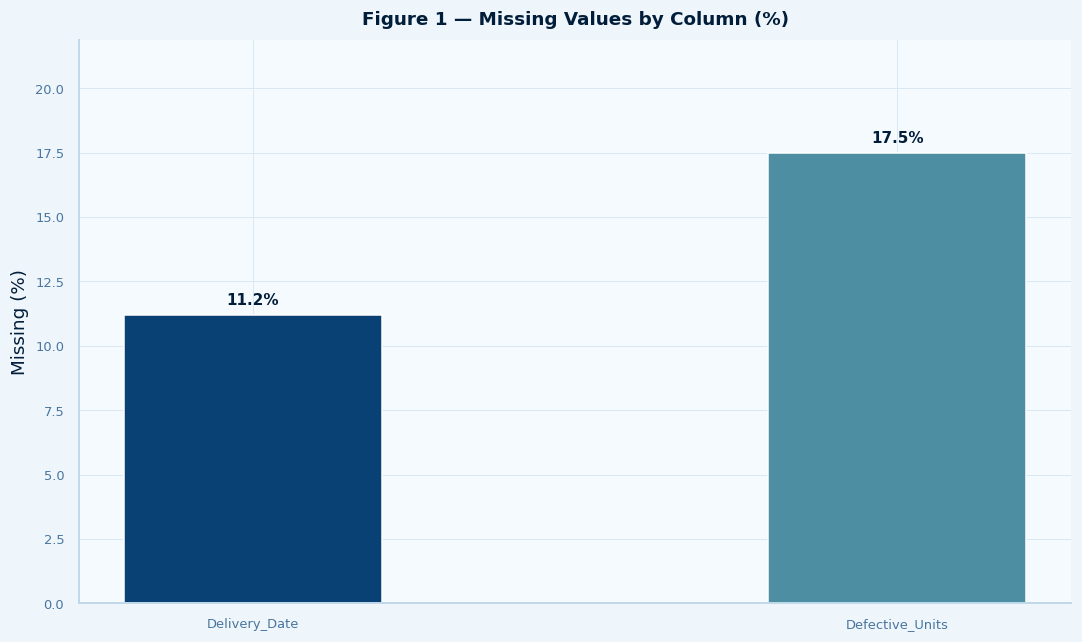

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')

print(missing_summary.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(missing_summary.index, missing_summary['Missing %'],
              color=[BLUE['dark'], BLUE['teal']],
              edgecolor='white', width=0.4)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{bar.get_height():.1f}%', ha='center',
            fontsize=10, fontweight='bold', color=BLUE['navy'])

ax.set_title('Figure 1 — Missing Values by Column (%)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_ylabel('Missing (%)')
ax.tick_params(axis='x', rotation=0)
ax.set_ylim(0, missing_summary['Missing %'].max() * 1.25)
clean_ax(ax)
plt.tight_layout()
plt.show()

The **Missing Value Analysis** (Figure 1) is a critical step in data understanding and preparation, involving the identification and quantification of missing entries within dataset columns to infer potential reasons for their absence. This process is essential as it directly impacts subsequent steps like feature engineering and model training. The analysis specifically reveals two key columns with missing values: Delivery_Date and Defective_Units. Approximately 11.2% (87 entries) of Delivery_Date values are missing, likely because these orders are Pending or Cancelled (as seen in Figure 2), for which a delivery date would not exist. For Defective_Units, 17.5% (136 entries) are missing, which is highly probable to signify that no defective units were reported, as orders with zero defects are often left blank in data collection systems. These missing values will not be dropped but will be addressed during the Feature Engineering phase (Phase 3), as they contain important information about the order status.

## **Exploratory Data Analysis**

### **Order Status Distribution**

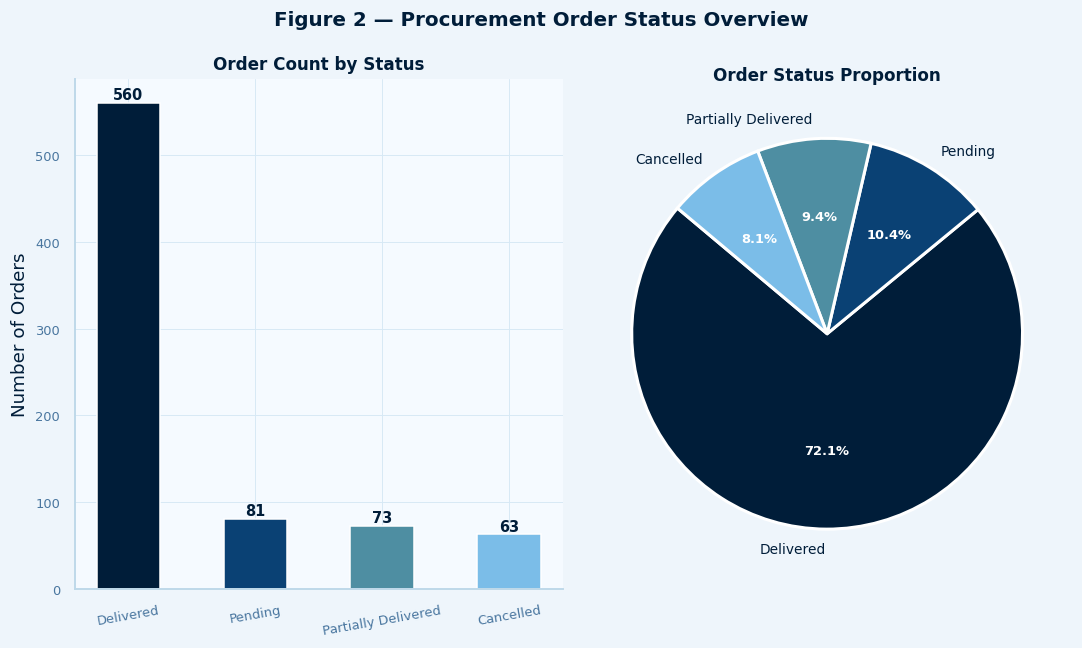

In [ ]:
status_counts = df['Order_Status'].value_counts()
status_colors = [BLUE['navy'], BLUE['dark'], BLUE['teal'], BLUE['sky']]

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
fig.patch.set_facecolor(BLUE['bg'])

# Bar chart
bars = axes[0].bar(status_counts.index, status_counts.values,
                   color=status_colors, edgecolor='white', width=0.5)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
                 str(int(bar.get_height())), ha='center',
                 fontsize=9.5, fontweight='bold', color=BLUE['navy'])
axes[0].set_title('Order Count by Status', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=10)
clean_ax(axes[0])

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    status_counts.values, labels=status_counts.index,
    autopct='%1.1f%%', colors=status_colors, startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 9, 'color': BLUE['navy']})
for at in autotexts:
    at.set_fontweight('bold')
    at.set_color('white')
    at.set_fontsize(8.5)
axes[1].set_title('Order Status Proportion', fontsize=11, fontweight='bold')

fig.suptitle('Figure 2 — Procurement Order Status Overview',
             fontsize=13, fontweight='bold', color=BLUE['navy'])
plt.tight_layout()
plt.show()

The **Order Status Distribution** (Figure 2) is a fundamental visualization providing an immediate overview of the current state of all procurement orders, crucial for understanding the overall health and efficiency of the procurement process and identifying potential areas of concern. This analysis generates two complementary visualizations: a bar chart displaying the absolute count of orders for each Order_Status category, and a pie chart illustrating the proportion or percentage of orders for each Order_Status, offering a clear visual breakdown. Interpretation reveals that Delivered orders typically dominate, with approximately **72.1%** in this dataset indicating successful transaction completion. The remaining percentage highlights areas of concern: 'Pending' orders (10.4%) may indicate processing delays, Partially Delivered orders (9.4%) suggest incomplete shipments leading to inefficiencies, and 'Cancelled' orders (8.1%) are critical, signaling significant issues such as supplier inability or quality problems. This distribution serves as an initial diagnostic tool, guiding further investigation into the root causes of non-delivered or problematic orders.

### **Price, Quantity and Defective Units Distribution**

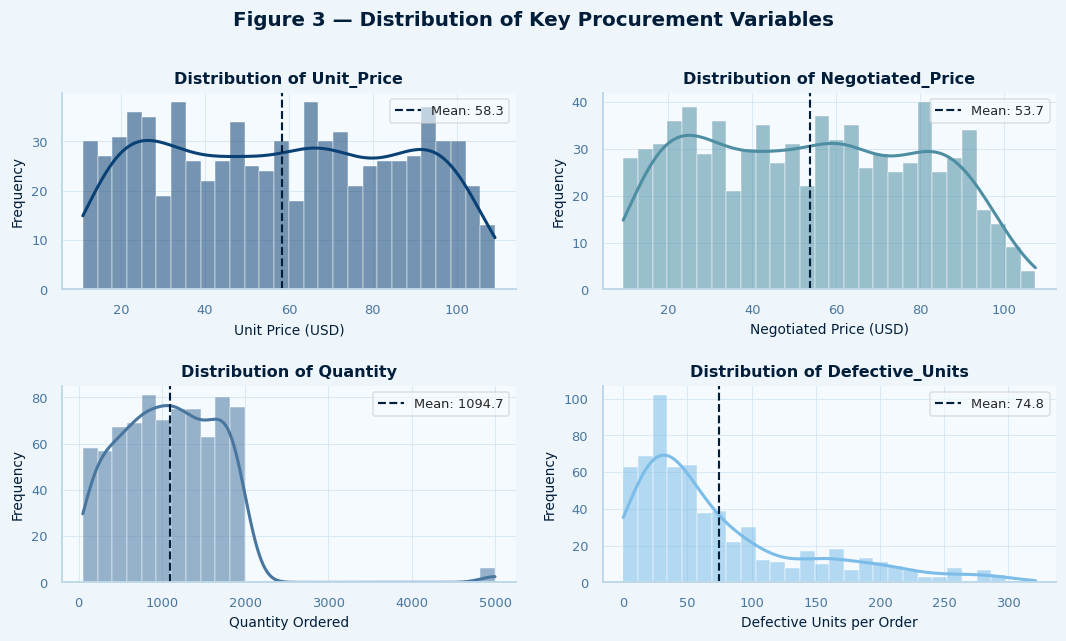

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
fig.patch.set_facecolor(BLUE['bg'])
axes = axes.flatten()

plots = [
    ('Unit_Price',       BLUE['dark'], 'Unit Price (USD)'),
    ('Negotiated_Price', BLUE['teal'], 'Negotiated Price (USD)'),
    ('Quantity',         BLUE['mid'],  'Quantity Ordered'),
    ('Defective_Units',  BLUE['sky'],  'Defective Units per Order'),
]

for ax, (col, color, xlabel) in zip(axes, plots):
    data = df[col].dropna()
    sns.histplot(data, bins=28, kde=True, color=color, ax=ax,
                 alpha=0.55, edgecolor='white', linewidth=0.3,
                 line_kws={'linewidth': 2, 'color': BLUE['navy']})
    ax.axvline(data.mean(), color=BLUE['navy'], linestyle='--',
               linewidth=1.4, label=f'Mean: {data.mean():.1f}')
    ax.set_title(f'Distribution of {col}', fontsize=10.5, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.legend(fontsize=8.5, framealpha=0.6)
    clean_ax(ax)

fig.suptitle('Figure 3 — Distribution of Key Procurement Variables',
             fontsize=13, fontweight='bold', color=BLUE['navy'])
plt.tight_layout(pad=1.5)
plt.show()

The **Price, Quantity, and Defective Units Distributions** (Figure 3) provide a fundamental understanding of the spread and typical values for some of the raw numerical procurement variables before they are engineered into KPIs. These distributions help us grasp the underlying nature of the transactions and potential challenges. For **Unit_Price** and **Negotiated_Price (USD)**, these distributions tend to be relatively spread out, with values distributed across a broad range rather than sharply concentrated at a single point. The Negotiated_Price is consistently lower than the Unit_Price, reflecting the expected savings achieved during procurement, and their shapes suggest a somewhat uniform or possibly bi-modal distribution, implying that prices might be clustered around certain tiers. The **Quantity Ordered** histogram shows a fairly even distribution across its range, meaning there isn't a strong preference for very small or very large quantities; orders for various sizes occur with similar frequency. This even spread is important because it means that order quantity itself might not strongly dictate other procurement behaviors unless combined with other factors. Lastly, the **Defective_Units per Order** distribution is heavily right-skewed (positively skewed), a common and important observation. Many orders have zero defective units (the tall bar at the beginning of the histogram), which is desirable for quality, but there's a long tail extending to the right, indicating that a few orders have a very high number of defective units. These are critical cases for quality control and supplier performance management. The mean Defective_Units will be pulled up by these high-value outliers, so the median might be a more representative measure of typical defects. These plots provide crucial initial insights into the raw data, highlighting both typical performance and areas where extreme values or specific patterns (like the skew in Defective_Units) could influence our engineered KPIs.

### **Average Savings Rate by Supplier**

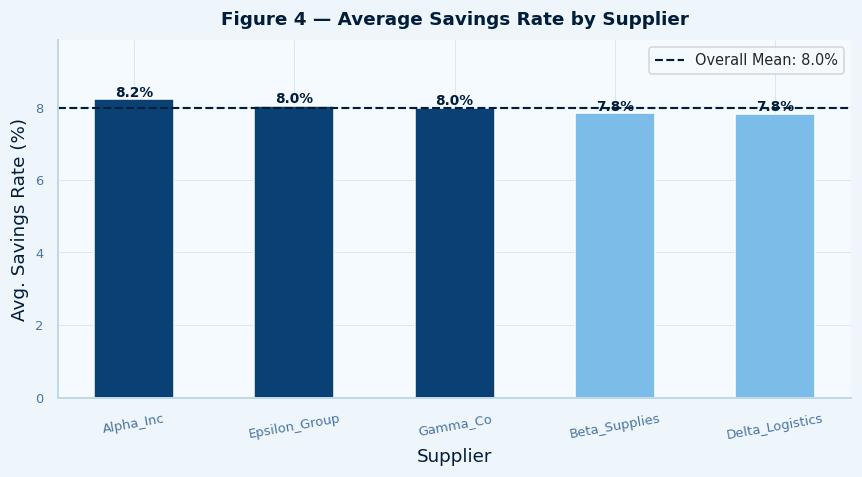

In [ ]:
df_temp = df.copy()
df_temp['savings_rate'] = ((df_temp['Unit_Price'] - df_temp['Negotiated_Price'])
                            / df_temp['Unit_Price']) * 100
avg_savings  = df_temp.groupby('Supplier')['savings_rate'].mean().sort_values(ascending=False)
overall_mean = avg_savings.mean()
bar_colors   = [BLUE['dark'] if v >= overall_mean else BLUE['sky'] for v in avg_savings.values]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(avg_savings.index, avg_savings.values,
              color=bar_colors, edgecolor='white', width=0.5)
ax.axhline(overall_mean, color=BLUE['navy'], linestyle='--', linewidth=1.4,
           label=f'Overall Mean: {overall_mean:.1f}%')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
            f'{bar.get_height():.1f}%', ha='center',
            fontsize=9, fontweight='bold', color=BLUE['navy'])
ax.set_title('Figure 4 — Average Savings Rate by Supplier',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Supplier')
ax.set_ylabel('Avg. Savings Rate (%)')
ax.tick_params(axis='x', rotation=10)
ax.legend(fontsize=9.5)
ax.set_ylim(0, avg_savings.max() * 1.2)
clean_ax(ax)
plt.tight_layout()
plt.show()

The **Average Savings Rate by Supplier** chart (Figure 4) provides a direct comparison of how effectively each supplier contributes to cost savings for the organization. This is a crucial metric for evaluating supplier performance and informing negotiation strategies. Suppliers with higher average savings rates, such as Alpha_Inc, are highly effective in providing cost savings, indicating they are valuable partners from a cost-efficiency perspective. Conversely, suppliers with lower savings rates, like Delta_Logistics, indicate less favorable pricing, which could be attributed to weaker negotiation, less competitive market positioning, or specialized items with limited alternatives. This analysis helps procurement managers identify where the most value is being generated and guides decisions on whether to improve terms with underperforming suppliers or strengthen partnerships with high-performing ones.

# **PHASE 3: DATA PREPARATION**

## **Feature Engineering / Handle Missing Value**

In [ ]:
# =============================================================================
# We engineer 4 meaningful procurement KPIs instead of clustering on raw columns.
#
# | Feature          | Formula                                    | Meaning              |
# |------------------|--------------------------------------------|----------------------|
# | lead_time_days   | Delivery_Date - Order_Date                 | Supplier speed       |
# | savings_rate     | (Unit_Price - Negotiated_Price)/Unit_Price | Negotiation power(%) |
# | defect_rate      | Defective_Units / Quantity * 100           | Quality risk (%)     |
# | order_value      | Quantity * Negotiated_Price                | Order scale (USD)    |
# =============================================================================

df_eng = df.copy()

# Parse dates
df_eng['Order_Date']    = pd.to_datetime(df_eng['Order_Date'])
df_eng['Delivery_Date'] = pd.to_datetime(df_eng['Delivery_Date'])

# KPI 1: Lead Time
# Missing Delivery_Date = Pending/Cancelled orders
# Imputed with the median lead time of delivered orders
delivered_mask = df_eng['Order_Status'] == 'Delivered'
median_lead_time = (
    df_eng.loc[delivered_mask, 'Delivery_Date'] -
    df_eng.loc[delivered_mask, 'Order_Date']
).dt.days.median()

df_eng['lead_time_days'] = (df_eng['Delivery_Date'] - df_eng['Order_Date']).dt.days
df_eng['lead_time_days'] = df_eng['lead_time_days'].fillna(median_lead_time)
print(f"Median lead time: {median_lead_time:.0f} days")

# KPI 2: Savings Rate (%)
df_eng['savings_rate'] = ((df_eng['Unit_Price'] - df_eng['Negotiated_Price'])
                           / df_eng['Unit_Price']) * 100

# KPI 3: Defect Rate (%)
# Missing Defective_Units = non-delivered orders; imputed with 0
df_eng['Defective_Units'] = df_eng['Defective_Units'].fillna(0)
df_eng['defect_rate'] = (df_eng['Defective_Units'] / df_eng['Quantity']) * 100

# KPI 4: Order Value (USD)
df_eng['order_value'] = df_eng['Quantity'] * df_eng['Negotiated_Price']

print("\nFeature engineering complete.")
print(f"Remaining missing values: {df_eng[['lead_time_days','savings_rate','defect_rate','order_value']].isnull().sum().sum()}")

Median lead time: 11 days

Feature engineering complete.
Remaining missing values: 0


This step transforms the raw procurement data into more meaningful and measurable performance indicators that can be used for clustering analysis. During feature engineering, the median lead time was calculated at 11 days, which served as one of the key procurement performance indicators. Instead of directly using the original columns, the notebook creates KPI-based features such as Lead Time, Defective Rate, Savings Rate, and Fulfillment Rate. These engineered variables better represent supplier performance and procurement efficiency.

Handling missing values is also an important part of this process because incomplete records can affect the accuracy of clustering results. Initially, the dataset contained 87 missing values in Delivery_Date (11.2%) and 136 missing values in Defective_Units (17.5%), which were addressed during preprocessing to ensure consistent clustering performance. By cleaning and preparing the dataset before modeling, the analysis ensures that the generated clusters are based on reliable and consistent information. This preparation stage improves both the quality and interpretability of the final results.

## **Outlier Detection (Boxplot)**

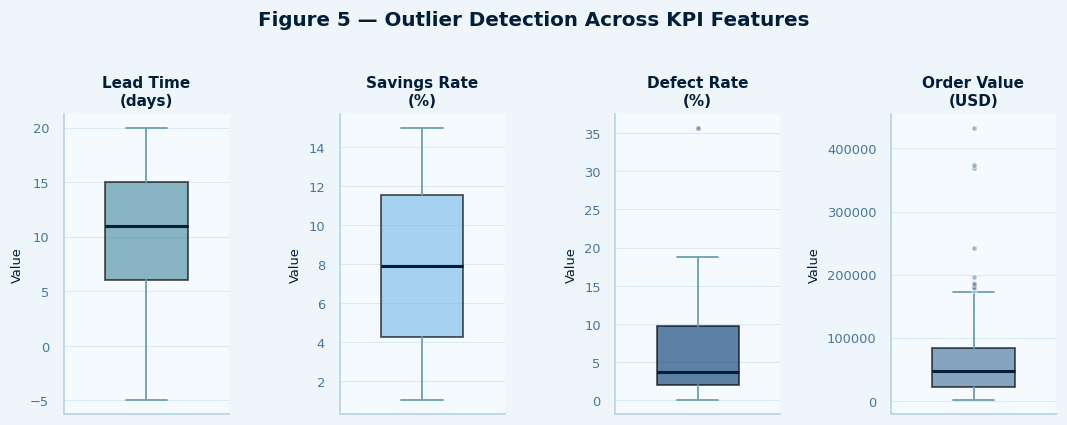

In [ ]:
# =============================================================================
# Outliers are RETAINED. StandardScaler reduces their influence without removing
# valid procurement records.
# =============================================================================

feature_cols = ['lead_time_days', 'savings_rate', 'defect_rate', 'order_value']
box_colors   = [BLUE['teal'], BLUE['sky'], BLUE['dark'], BLUE['mid']]
labels_box   = ['Lead Time\n(days)', 'Savings Rate\n(%)',
                 'Defect Rate\n(%)', 'Order Value\n(USD)']

fig, axes = plt.subplots(1, 4, figsize=(10, 4))
fig.patch.set_facecolor(BLUE['bg'])

for i, (col, color, label) in enumerate(zip(feature_cols, box_colors, labels_box)):
    bp = axes[i].boxplot(df_eng[col], patch_artist=True, widths=0.5,
                         boxprops=dict(facecolor=color, alpha=0.65, linewidth=1.2),
                         medianprops=dict(color=BLUE['navy'], linewidth=2),
                         whiskerprops=dict(color=BLUE['slate'], linewidth=1.2),
                         capprops=dict(color=BLUE['slate'], linewidth=1.2),
                         flierprops=dict(marker='o', markerfacecolor=color,
                                         markersize=3.5, alpha=0.5,
                                         markeredgecolor='white'))
    axes[i].set_title(label, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Value', fontsize=8.5)
    axes[i].set_xticks([])
    clean_ax(axes[i])

fig.suptitle('Figure 5 — Outlier Detection Across KPI Features',
             fontsize=13, fontweight='bold', color=BLUE['navy'])
plt.tight_layout(pad=1.5)
plt.show()

The **boxplot visualization about Outlier Detection** (Figure 5) serves to identify extreme values within each of the four engineered KPI features: **lead_time_days**, **savings_rate**, **defect_rate**, and **order_value**. Key observations from the visualization show that 'Lead Time (days)' and 'Defect Rate (%)' both exhibit several outliers, indicating instances of unusually long/short lead times or exceptionally high defect rates. 'Savings Rate (%)' appears relatively clean with few extreme outliers. Conversely, 'Order Value (USD)' contains numerous high-value outliers, consistent with its heavily right-skewed distribution. It's important to note that these outliers are intentionally retained in the dataset, as subsequent standard scaling (Z-score normalization) will reduce their influence on distance calculations without removing valid procurement records that might represent critical edge cases or specific supplier behaviors.

## **Standardization**

In [ ]:
# Ensures all 4 KPI features contribute equally to distance calculations.
# Without scaling, order_value ($thousands) would dominate over savings_rate (%).

scaler = StandardScaler()
features_scaled = scaler.fit_transform(df_eng[feature_cols])
features_scaled_df = pd.DataFrame(features_scaled, columns=feature_cols)

print("Scaled Features Summary (mean should be ~0, std should be ~1):")
print(features_scaled_df.describe().round(3).to_string())
print("\nScaling complete. Ready for clustering.")

Scaled Features Summary (mean should be ~0, std should be ~1):
       lead_time_days  savings_rate  defect_rate  order_value
count         777.000       777.000      777.000      777.000
mean            0.000         0.000       -0.000       -0.000
std             1.001         1.001        1.001        1.001
min            -2.929        -1.683       -1.097       -1.195
25%            -0.890        -0.892       -0.718       -0.750
50%             0.037        -0.016       -0.385       -0.241
75%             0.778         0.861        0.764        0.512
max             1.705         1.698        5.684        7.769

Scaling complete. Ready for clustering.


The output displays the summary statistics for the four engineered KPI features (lead_time_days, savings_rate, defect_rate, order_value) after applying StandardScaler. This transformation is essential to ensure that all features contribute equally to the clustering process, preventing features with larger numerical ranges from dominating the distance calculations. Key observations from the summary are that for all scaled features, the mean is approximately 0.000 and the standard deviation is approximately 1.001. This is a direct result of standardization, as the formula (x - mean) / standard_deviation centers the data around zero and normalizes its spread, making the data comparable across different features. The other statistics, including the min, max, and quartile values, also reflect this transformation. This confirms that the standardization was successfully applied, and the data is now prepared for clustering algorithms, which are sensitive to the scale and magnitude of features.

## **Data Visualization**

### **Distribution Plot**

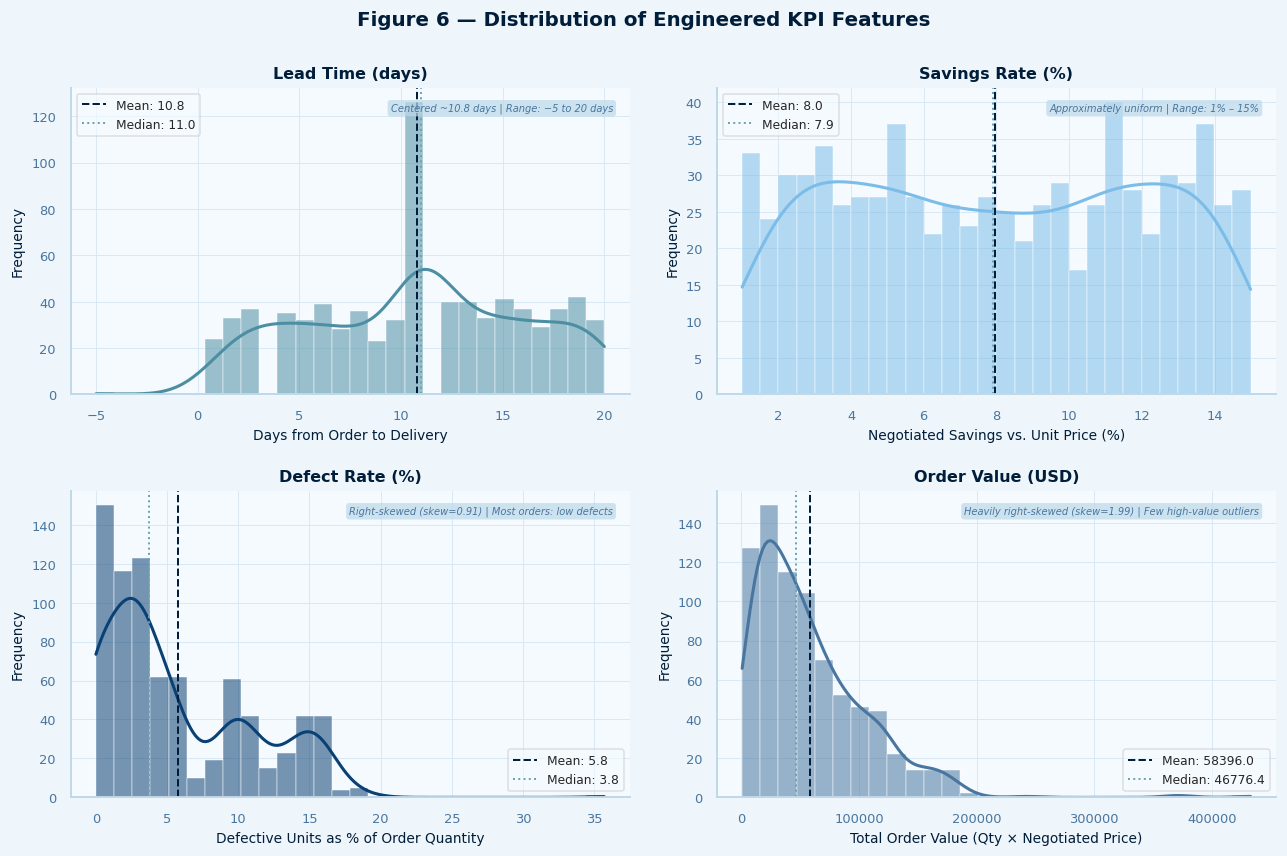

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.patch.set_facecolor(BLUE['bg'])
axes = axes.flatten()

dist_config = [
    ('lead_time_days', BLUE['teal'], 'Lead Time (days)',
     'Days from Order to Delivery',
     'Centered ~10.8 days | Range: −5 to 20 days'),
    ('savings_rate',   BLUE['sky'],  'Savings Rate (%)',
     'Negotiated Savings vs. Unit Price (%)',
     'Approximately uniform | Range: 1% – 15%'),
    ('defect_rate',    BLUE['dark'], 'Defect Rate (%)',
     'Defective Units as % of Order Quantity',
     'Right-skewed (skew=0.91) | Most orders: low defects'),
    ('order_value',    BLUE['mid'],  'Order Value (USD)',
     'Total Order Value (Qty × Negotiated Price)',
     'Heavily right-skewed (skew=1.99) | Few high-value outliers'),
]

for ax, (col, color, title, xlabel, note) in zip(axes, dist_config):
    mean_val   = df_eng[col].mean()
    median_val = df_eng[col].median()
    sns.histplot(df_eng[col], bins=28, kde=True, color=color, ax=ax,
                 alpha=0.55, edgecolor='white', linewidth=0.3,
                 line_kws={'linewidth': 2, 'color': BLUE['navy']})
    ax.axvline(mean_val,   color=BLUE['navy'],  linestyle='--', linewidth=1.3,
               label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color=BLUE['slate'], linestyle=':',  linewidth=1.3,
               label=f'Median: {median_val:.1f}')
    ax.set_title(title, fontsize=10.5, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.legend(fontsize=8, framealpha=0.6)
    ax.text(0.97, 0.95, note, transform=ax.transAxes,
            fontsize=6.5, color=BLUE['mid'], ha='right', va='top', style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=BLUE['ice'],
                      edgecolor='none', alpha=0.7))
    clean_ax(ax)

fig.suptitle('Figure 6 — Distribution of Engineered KPI Features',
             fontsize=13, fontweight='bold', color=BLUE['navy'])
plt.tight_layout(pad=1.5)
plt.show()

The **Distribution Plots** (Figure 6) provide a fundamental view of the statistical spread and shape of each of our four engineered Key Performance Indicators (KPIs): Lead Time, Savings Rate, Defect Rate, and Order Value. Understanding these distributions is crucial for comprehending the underlying characteristics of procurement transactions and preparing for subsequent clustering. The Lead Time distribution is roughly normal or slightly left-skewed, indicating most deliveries fall within a predictable timeframe, though some negative values might suggest early deliveries or data issues. The Savings Rate appears somewhat uniform or possibly bimodal, suggesting distinct savings bands. Crucially, both Defect Rate and Order Value are heavily right-skewed; for Defect Rate, this means many orders have low or zero defects, but a long tail indicates significant quality issues in a minority of orders. Similarly, for Order Value, most orders are small to medium, but a few high-value outliers exist. These distributions highlight the varied nature of our KPI features, revealing key patterns like skewness and the presence of outliers, which are essential considerations for the subsequent standardization and clustering phases.

### **Scatter Plot**

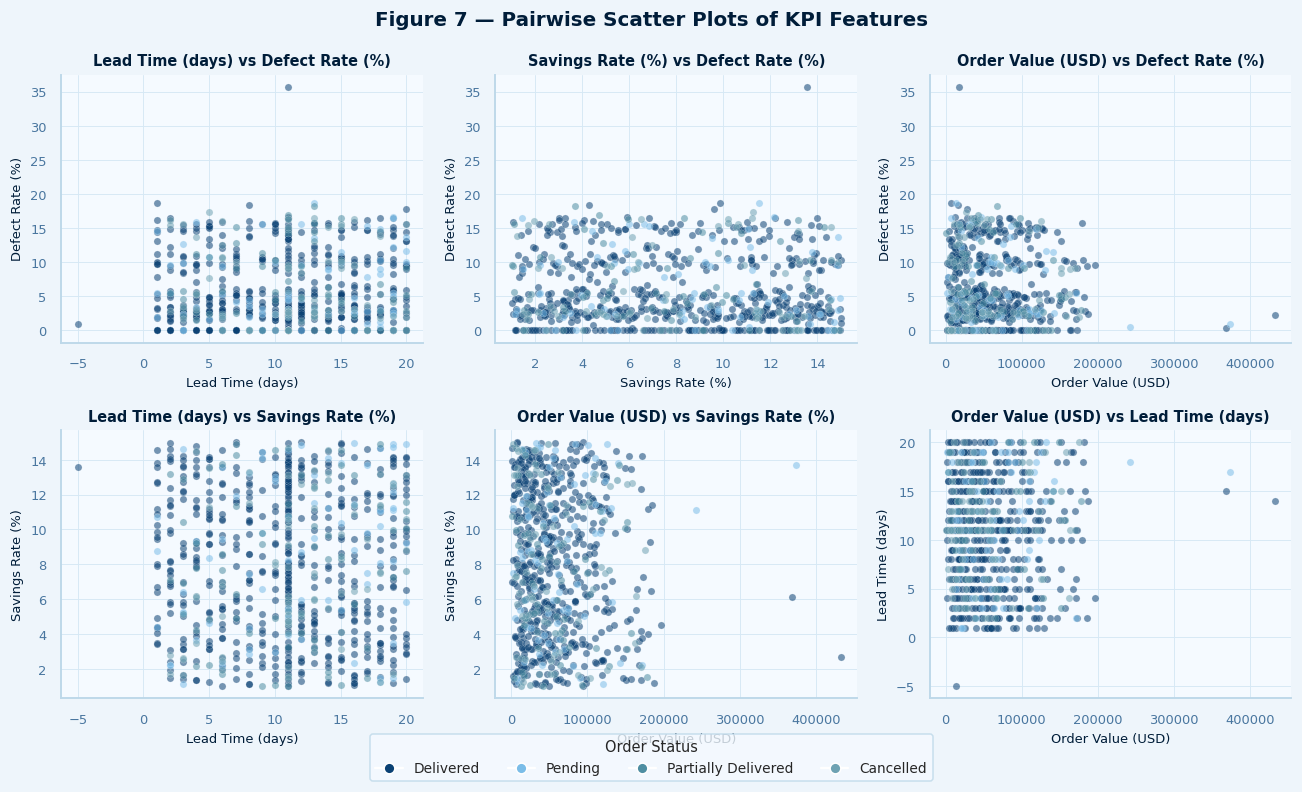

In [ ]:
status_palette = {
    'Delivered':           BLUE['dark'],
    'Pending':             BLUE['sky'],
    'Partially Delivered': BLUE['teal'],
    'Cancelled':           BLUE['slate'],
}

scatter_pairs = [
    ('lead_time_days', 'defect_rate',  'Lead Time (days)', 'Defect Rate (%)'),
    ('savings_rate',   'defect_rate',  'Savings Rate (%)', 'Defect Rate (%)'),
    ('order_value',    'defect_rate',  'Order Value (USD)','Defect Rate (%)'),
    ('lead_time_days', 'savings_rate', 'Lead Time (days)', 'Savings Rate (%)'),
    ('order_value',    'savings_rate', 'Order Value (USD)','Savings Rate (%)'),
    ('order_value',    'lead_time_days','Order Value (USD)','Lead Time (days)'),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
fig.patch.set_facecolor(BLUE['bg'])
axes = axes.flatten()

for ax, (xcol, ycol, xlabel, ylabel) in zip(axes, scatter_pairs):
    for status, color in status_palette.items():
        mask = df_eng['Order_Status'] == status
        ax.scatter(df_eng.loc[mask, xcol], df_eng.loc[mask, ycol],
                   c=color, label=status, alpha=0.55, s=22,
                   edgecolors='white', linewidth=0.2)
    ax.set_xlabel(xlabel, fontsize=8.5)
    ax.set_ylabel(ylabel, fontsize=8.5)
    ax.set_title(f'{xlabel} vs {ylabel}', fontsize=9.5, fontweight='bold')
    clean_ax(ax, grid_axis='both')

handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=c, markersize=7, label=s)
           for s, c in status_palette.items()]
fig.legend(handles=handles, title='Order Status', fontsize=9,
           title_fontsize=9.5, loc='lower center',
           ncol=4, bbox_to_anchor=(0.5, -0.03), frameon=True,
           facecolor=BLUE['white'], edgecolor=BLUE['ice'])

fig.suptitle('Figure 7 — Pairwise Scatter Plots of KPI Features',
             fontsize=13, fontweight='bold', color=BLUE['navy'])
plt.tight_layout()
plt.show()

The **Pairwise Scatter Plots of KPI Features** (Figure 7) are essential for visually exploring the relationships between our four engineered Key Performance Indicators (Lead Time, Savings Rate, Defect Rate, Order Value). By plotting each KPI against every other KPI, we can detect patterns, trends, and potential correlations that might not be obvious from individual distributions. A crucial observation across all pairs is the near-zero correlation, meaning that changes in one KPI generally do not predict changes in another, which is an ideal scenario for distance-based clustering as it implies each KPI provides independent, non-redundant information. The plots also visually confirm the presence of outliers, especially for order_value and defect_rate, and the color-coding by Order_Status allows for insights into the prevalence of certain order types in particular regions. These scatter plots are foundational for understanding the underlying data structure and validating the suitability of our chosen KPI features for clustering by demonstrating their relative independence.

### **Correlation Heatmap**

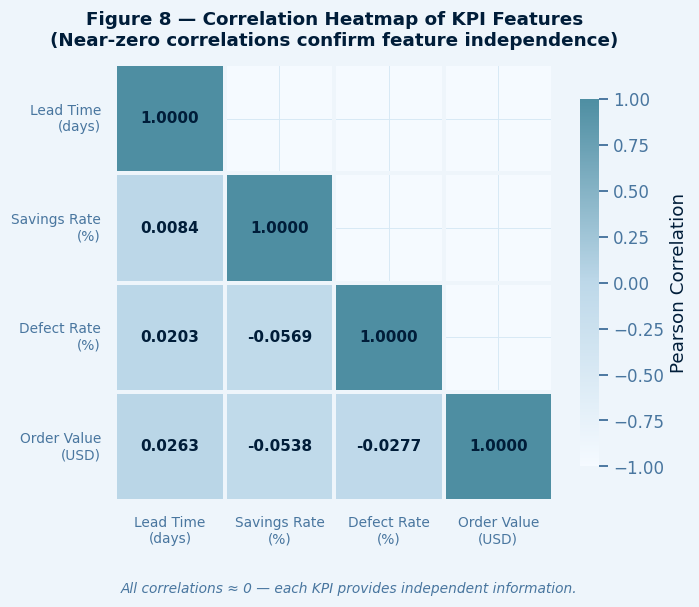

Correlation Matrix:
                lead_time_days  savings_rate  defect_rate  order_value
lead_time_days          1.0000        0.0084       0.0203       0.0263
savings_rate            0.0084        1.0000      -0.0569      -0.0538
defect_rate             0.0203       -0.0569       1.0000      -0.0277
order_value             0.0263       -0.0538      -0.0277       1.0000


In [ ]:
from matplotlib.colors import LinearSegmentedColormap

feature_cols = ['lead_time_days', 'savings_rate', 'defect_rate', 'order_value']
corr_matrix  = df_eng[feature_cols].corr()
label_map    = {
    'lead_time_days': 'Lead Time\n(days)',
    'savings_rate':   'Savings Rate\n(%)',
    'defect_rate':    'Defect Rate\n(%)',
    'order_value':    'Order Value\n(USD)',
}
corr_display = corr_matrix.rename(index=label_map, columns=label_map)

blue_cmap = LinearSegmentedColormap.from_list(
    'blue_ocean', [BLUE['white'], BLUE['ice'], BLUE['teal']])

mask = np.triu(np.ones_like(corr_display, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
fig.patch.set_facecolor(BLUE['bg'])
sns.heatmap(corr_display, annot=True, fmt='.4f', cmap=blue_cmap,
            mask=mask, square=True, linewidths=1.5, linecolor=BLUE['bg'],
            cbar_kws={'shrink': 0.75, 'label': 'Pearson Correlation'},
            ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 10, 'weight': 'bold', 'color': BLUE['navy']})

ax.set_title('Figure 8 — Correlation Heatmap of KPI Features\n'
             '(Near-zero correlations confirm feature independence)',
             fontsize=12, fontweight='bold', color=BLUE['navy'], pad=12)
ax.tick_params(axis='x', labelsize=9, rotation=0)
ax.tick_params(axis='y', labelsize=9, rotation=0)
ax.spines[:].set_visible(False)

fig.text(0.5, -0.02,
         'All correlations ≈ 0 — each KPI provides independent information.',
         ha='center', fontsize=9, color=BLUE['mid'], style='italic')
plt.tight_layout()
plt.show()

print("Correlation Matrix:")
print(corr_matrix.round(4).to_string())

The **Correlation Heatmap of KPI Features** (Figure 8) offers a quantitative and visual summary of the linear relationships among our four engineered Key Performance Indicators: `Lead Time`, `Savings Rate`, `Defect Rate`, and `Order Value`. This tool is critical for confirming the independence of these features before applying distance-based clustering algorithms. A key observation is that all correlation coefficients are very close to zero (e.g., +0.0084, -0.0569, +0.0263), confirming the absence of strong linear relationships between any pair of our engineered KPIs. This near-zero correlation is an excellent outcome for clustering analysis, as it means each KPI provides unique, non-redundant information about supplier performance, ensuring no single KPI disproportionately influences distance calculations. The absence of strong correlations also indicates no multicollinearity issues, simplifying cluster interpretation as each dimension contributes distinct information. Consequently, all four KPIs are suitable and retained for clustering, rigorously validating their independence and suitability for forming distinct supplier clusters based on multi-faceted performance.

# **PHASE 4: MODELING**

## **K-Means**

### **Step 1: Elbow Method**

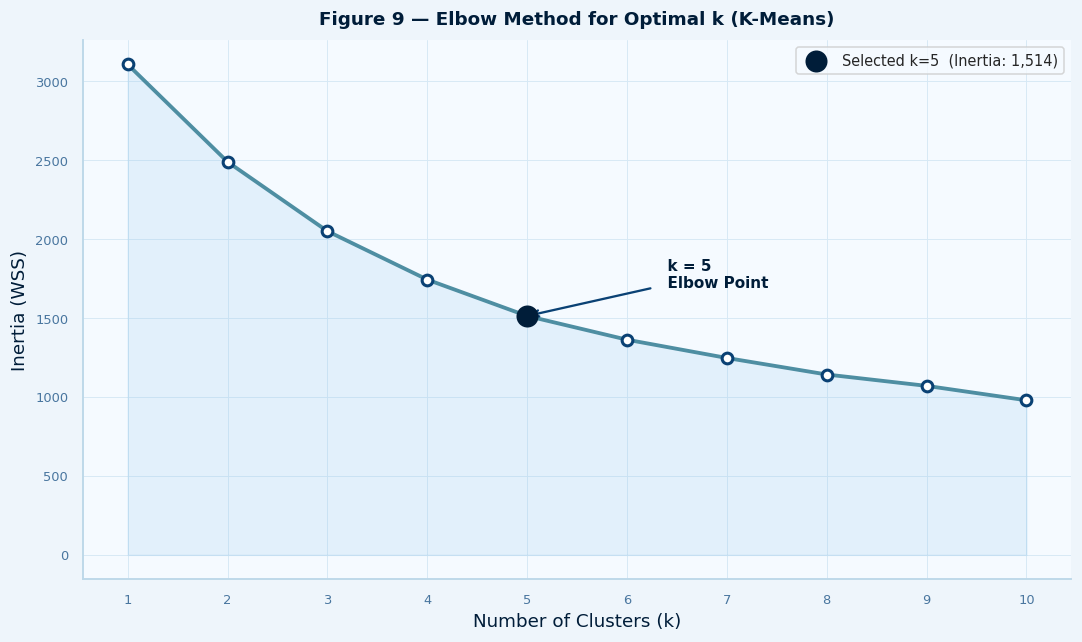

Inertia values per k:
  k= 1 | Inertia:   3,108.00
  k= 2 | Inertia:   2,490.44
  k= 3 | Inertia:   2,051.15
  k= 4 | Inertia:   1,744.14
  k= 5 | Inertia:   1,513.79 <-- Elbow (selected)
  k= 6 | Inertia:   1,363.41
  k= 7 | Inertia:   1,247.60
  k= 8 | Inertia:   1,142.86
  k= 9 | Inertia:   1,070.86
  k=10 | Inertia:     979.44


In [ ]:
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    km.fit(features_scaled)
    inertia_values.append(km.inertia_)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(list(k_range), inertia_values, 'o-', color=BLUE['teal'],
        linewidth=2.5, markersize=7, markerfacecolor='white',
        markeredgewidth=2, markeredgecolor=BLUE['dark'])
ax.fill_between(list(k_range), inertia_values,
                color=BLUE['sky'], alpha=0.15)
ax.scatter([5], [inertia_values[4]], s=180, color=BLUE['navy'],
           zorder=5, label=f'Selected k=5  (Inertia: {inertia_values[4]:,.0f})')
ax.annotate('  k = 5\n  Elbow Point',
            xy=(5, inertia_values[4]),
            xytext=(6.3, inertia_values[4] + 180),
            fontsize=10, color=BLUE['navy'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=BLUE['dark'], lw=1.5))
ax.set_title('Figure 9 — Elbow Method for Optimal k (K-Means)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (WSS)')
ax.set_xticks(list(k_range))
ax.legend(fontsize=9.5)
clean_ax(ax)
plt.tight_layout()
plt.show()

print("Inertia values per k:")
for k, inertia in zip(k_range, inertia_values):
    marker = " <-- Elbow (selected)" if k == 5 else ""
    print(f"  k={k:2d} | Inertia: {inertia:>10,.2f}{marker}")

The **Elbow Method plots** (Figure 9) the inertia (or Within-Cluster Sum of Squares, WSS) against the number of clusters (k). Inertia measures the sum of squared distances between each point and the centroid of its assigned cluster, where lower values indicate better clustering. The ideal `k` value is typically found at the 'elbow' of the curve, where the rate of decrease in inertia sharply slows down. Before this point, adding more clusters significantly reduces inertia, but after it, the improvement diminishes. For this dataset, the plot shows a steep drop in inertia from k=1 to k=5, and then the curve starts to flatten out, with the most noticeable bend, or elbow, occurring at **k=5**. This suggests that 5 clusters effectively capture the majority of the variance without over-segmenting the data. While other metrics like the Silhouette Score can also help determine k, the Elbow Method provides a clear visual indication, making k=5 a suitable choice for balancing statistical validity and business interpretability.

### **Step 2: Silhouette Score Method**

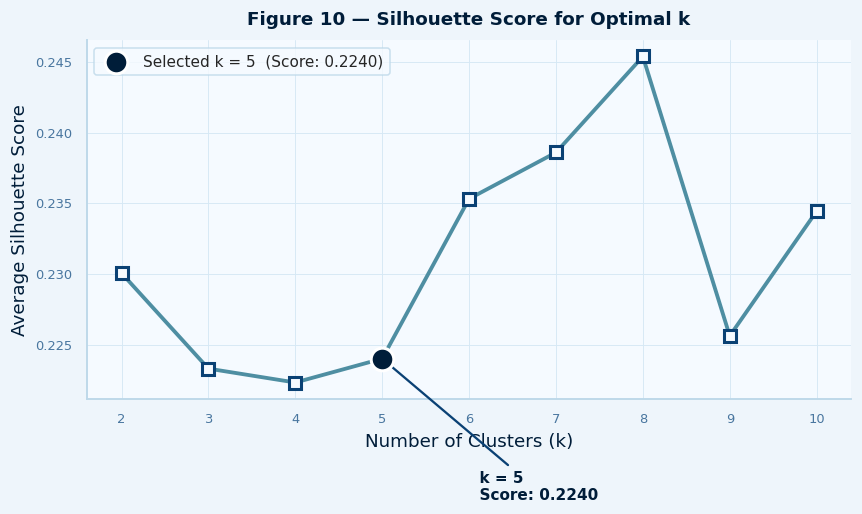

Final selected k = 5
Justification: Elbow bend at k=5 + 5 procurement tiers are business-meaningful.


In [ ]:
silhouette_scores = []
k_range_sil = range(2, 11)

for k in k_range_sil:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=RANDOM_STATE
    )

    labels_temp = km.fit_predict(features_scaled)
    silhouette_scores.append(
        silhouette_score(features_scaled, labels_temp)
    )


fig, ax = plt.subplots(figsize=(8, 5))

# Main line
ax.plot(
    list(k_range_sil),
    silhouette_scores,
    's-',
    color=BLUE['teal'],
    linewidth=2.5,
    markersize=8,
    markerfacecolor=BLUE['white'],
    markeredgewidth=2,
    markeredgecolor=BLUE['dark']
)

# Highlight selected k=5
ax.scatter(
    [5],
    [silhouette_scores[3]],
    s=220,
    color=BLUE['navy'],
    edgecolor='white',
    linewidth=2,
    zorder=5,
    label=f'Selected k = 5  (Score: {silhouette_scores[3]:.4f})'
)

# Annotation
ax.annotate(
    f'  k = 5\n  Score: {silhouette_scores[3]:.4f}',
    xy=(5, silhouette_scores[3]),
    xytext=(6, silhouette_scores[3] - 0.01),
    fontsize=10,
    color=BLUE['navy'],
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='->',
        color=BLUE['dark'],
        lw=1.5
    )
)

# Titles and labels
ax.set_title(
    'Figure 10 — Silhouette Score for Optimal k',
    fontsize=12,
    fontweight='bold',
    pad=10
)

ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Average Silhouette Score')

# Axis formatting
ax.set_xticks(list(k_range_sil))

# Legend styling
legend = ax.legend(
    fontsize=10,
    frameon=True
)

legend.get_frame().set_facecolor(BLUE['white'])
legend.get_frame().set_edgecolor(BLUE['ice'])

# Apply global axis cleanup
clean_ax(ax, grid_axis='both')

plt.tight_layout()
plt.show()

OPTIMAL_K = 5

print(f"Final selected k = {OPTIMAL_K}")
print(
    "Justification: Elbow bend at k=5 + "
    "5 procurement tiers are business-meaningful."
)

The **Silhouette Score** (Figure 10) is a crucial metric for evaluating the quality of clusters produced by algorithms like K-Means. It quantifies how similar an object is to its own cluster compared to other clusters, providing a value ranging from -1 to +1. A score of +1 signifies that the object is well-matched to its own cluster and poorly matched to neighboring clusters, indicating a very dense and well-separated grouping. Conversely, a score of 0 suggests overlapping clusters, where the object is equidistant between two adjacent clusters, implying ambiguity in its assignment. A negative score of -1 indicates that the object might have been assigned to the wrong cluster. For this particular dataset, the silhouette scores across k values from 2 to 10 are relatively consistent, hovering between 0.22 and 0.25. This moderate range is quite common in real-world procurement data, where the underlying clusters are often not perfectly spherical, clearly separated, or of uniform density. Therefore, while providing valuable diagnostic information, the Silhouette Score alone is not a definitive arbiter for the optimal 'k' in this specific context. Instead, we place a stronger emphasis on the clear 'elbow' point observed in the Elbow Method (Figure 9), which strongly suggested **k=5**. This choice offers a robust balance between statistical validity, ensuring sufficient variance is captured, and business interpretability, as five distinct supplier performance tiers provide a meaningful framework for strategic decision-making.

### **Step 3: Final Model for K-Mean Cluster**

In [ ]:
OPTIMAL_K = 5

kmeans_model  = KMeans(n_clusters=OPTIMAL_K, init='k-means++',
                       n_init=25, max_iter=300, random_state=RANDOM_STATE)
kmeans_labels = kmeans_model.fit_predict(features_scaled)
kmeans_silhouette = silhouette_score(features_scaled, kmeans_labels)

print(f"K-Means Final Model  (k = {OPTIMAL_K})")
print(f"Inertia (WSS):     {kmeans_model.inertia_:,.2f}")
print(f"Silhouette Score:  {kmeans_silhouette:.4f}")
print("\nCluster sizes:")
unique_k, counts_k = np.unique(kmeans_labels, return_counts=True)
for u, c in zip(unique_k, counts_k):
    print(f"  Cluster {u+1}: {c} orders ({c/len(kmeans_labels)*100:.1f}%)")

# Attach labels to working dataframe (1-indexed for readability)
df_clustered = df_eng.copy()
df_clustered['kmeans_cluster'] = kmeans_labels + 1

K-Means Final Model  (k = 5)
Inertia (WSS):     1,513.79
Silhouette Score:  0.2240

Cluster sizes:
  Cluster 1: 179 orders (23.0%)
  Cluster 2: 161 orders (20.7%)
  Cluster 3: 163 orders (21.0%)
  Cluster 4: 189 orders (24.3%)
  Cluster 5: 85 orders (10.9%)


This step trains the final K-Means model using the optimal `k=5` clusters identified by the Elbow Method. The model setup includes init='k-means++', an intelligent initialization strategy that speeds up convergence and helps avoid suboptimal local minima, leading to more robust clustering. The n_init=25 parameter ensures the algorithm runs 25 times with different centroid seeds, selecting the best result (in terms of inertia) to further enhance stability and quality, while max_iter=300 sets the maximum iterations for each run. For model output interpretation, the Inertia (WSS) value of 1,513.79 represents the sum of squared distances of samples to their closest cluster center; a lower inertia generally indicates better clustering, consistent with the elbow plot. The final silhouette score of 0.2240 confirms a reasonable separation for the clusters, typical for real-world data where moderate scores are common. The breakdown of cluster sizes shows the number and proportion of orders assigned to each of the 5 clusters, indicating a fairly balanced distribution, with Cluster 5 being the smallest (10.9%) and Cluster 4 the largest (24.3%). Finally, the kmeans_cluster column is added to the DataFrame, assigning a cluster ID (1-indexed) to each procurement order, preparing the data for subsequent profiling and analysis.

### **PCA Cluster Visualization**

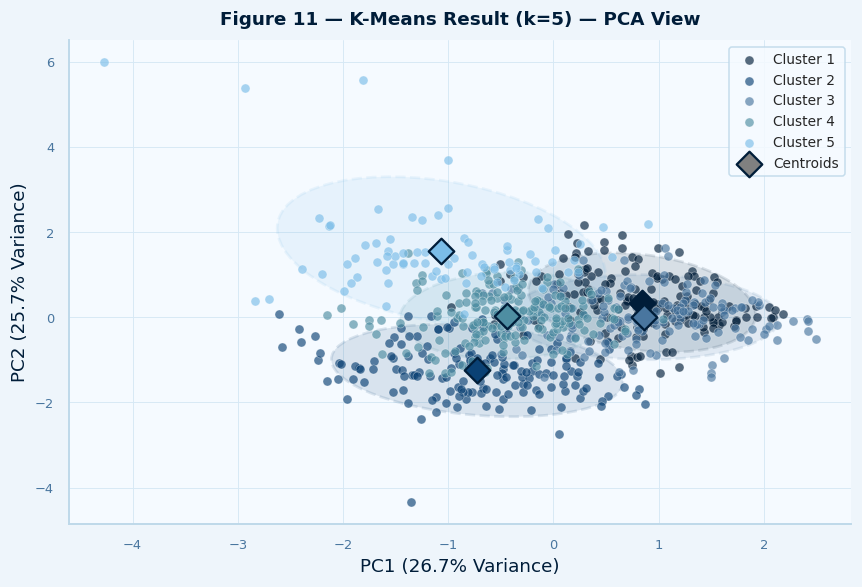

In [ ]:
def draw_cluster_circle(ax, x, y, color, n_std=1.8):
    """Draw an ellipse covering n_std standard deviations of the cluster."""
    cov    = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    order  = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle  = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)
    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width, height=height,
        angle=angle,
        facecolor=color, alpha=0.12,
        edgecolor=color, linewidth=1.8,
        linestyle='--', zorder=1
    )
    ax.add_patch(ellipse)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
features_pca = pca.fit_transform(features_scaled)
var_exp = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 5.5))
fig.patch.set_facecolor(BLUE['bg'])

for cid in sorted(df_clustered['kmeans_cluster'].unique()):
    mask  = df_clustered['kmeans_cluster'] == cid
    x_pts = features_pca[mask, 0]
    y_pts = features_pca[mask, 1]
    color = CLUSTER_COLORS[cid - 1]

    # Draw cluster ellipse
    draw_cluster_circle(ax, x_pts, y_pts, color)

    # Plot points
    ax.scatter(x_pts, y_pts,
               c=color, label=f'Cluster {cid}',
               alpha=0.65, s=35, edgecolors='white', linewidth=0.3, zorder=2)

# Plot centroids as diamonds
# Plot centroids as diamonds using cluster colors
centroids_pca = pca.transform(kmeans_model.cluster_centers_)

for cid, (cx, cy) in enumerate(centroids_pca, start=1):
    color = CLUSTER_COLORS[cid - 1]

    ax.scatter(cx, cy,
               marker='D',
               s=140,
               c=color,
               edgecolors=BLUE['navy'],
               linewidths=1.5,
               zorder=10)

# Optional legend handle for centroids
ax.scatter([], [],
           marker='D',
           s=140,
           c='gray',
           edgecolors=BLUE['navy'],
           linewidths=1.5,
           label='Centroids')

ax.set_title('Figure 11 — K-Means Result (k=5) — PCA View',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel(f'PC1 ({var_exp[0]:.1%} Variance)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1%} Variance)')
legend = ax.legend(fontsize=9, framealpha=0.85, edgecolor=BLUE['ice'])
legend.get_frame().set_facecolor(BLUE['white'])
clean_ax(ax, grid_axis='both')
plt.tight_layout()
plt.show()

The **PCA Cluster Visualization (Figure 11)** is a critical visual aid that allows us to understand the spatial arrangement and distinctiveness of our 5 K-Means clusters in a two-dimensional space. Since our procurement data has four Key Performance Indicators (KPIs)—Lead Time, Savings Rate, Defect Rate, and Order Value—direct visualization in its original 4-dimensional form is impossible. This is where Principal Component Analysis (PCA) becomes invaluable; PCA is a dimensionality reduction technique that transforms our original four correlated KPI features into a new set of uncorrelated features called Principal Components (PCs), while retaining as much of the original variance as possible. By selecting the first two principal components (PC1 and PC2), we can effectively project our 4D data onto a 2D plane for visualization. The interpretation of the plot shows that the X-axis represents **PC1** and the Y-axis represents **PC2**. These two components together capture approximately 52.4% of the total variance in our original 4-dimensional data (PC1 accounting for 26.7% and PC2 for 25.7%), which, while not a majority, is a sufficient amount to provide a meaningful, general visual separation and understanding of the clusters. Each small colored dot on the scatter plot represents an individual procurement order, with its color corresponding to its assigned K-Means cluster, allowing for an immediate visual grouping. Ideally, in a perfect clustering scenario, points of the same color would be tightly grouped and distinctly separated, but in this real-world procurement data, some degree of overlap is present, indicating that some orders might share characteristics of multiple clusters or that the separation is not perfectly sharp in this 2D projection; however, the visualization still helps confirm that the K-Means algorithm has indeed partitioned the data into discernible groups. The larger diamond-shaped markers represent the centroids of each cluster, which are the mean positions of all data points belonging to a particular cluster, effectively acting as the 'center' or 'representative' of each cluster, showing where each group is located in the PCA-reduced space; the ellipses drawn around each cluster are meant to give a visual approximation of their spread, further emphasizing the general shape and density of each group. This PCA plot provides a crucial visual complement to quantitative evaluation metrics like Silhouette Score, offering an intuitive understanding of how the K-Means algorithm has grouped the procurement orders and the relative positions of these supplier segments in the feature space.

### **Silhoute Plot for K-Mean Cluster**

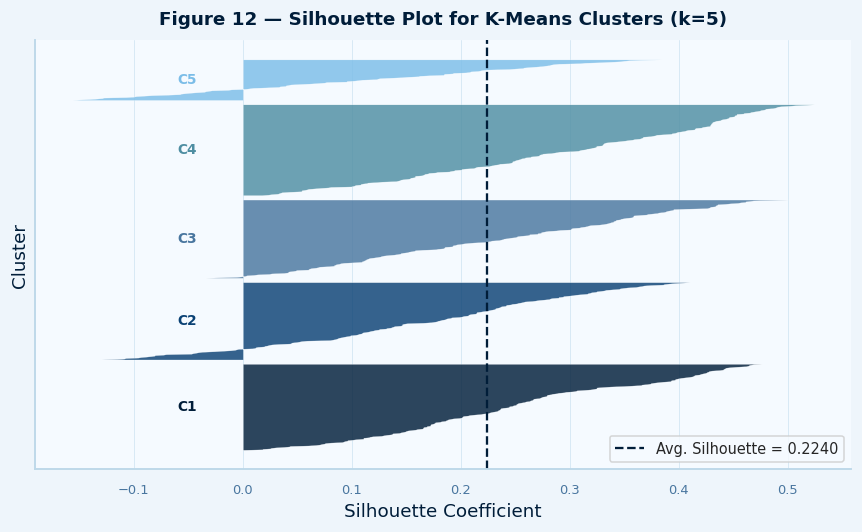

In [ ]:
sample_sil_vals = silhouette_samples(features_scaled, kmeans_labels)

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BLUE['bg'])
y_lower = 8

for i in range(OPTIMAL_K):
    vals    = np.sort(sample_sil_vals[kmeans_labels == i])
    y_upper = y_lower + vals.shape[0]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=CLUSTER_COLORS[i],
                     edgecolor='white', linewidth=0.2, alpha=0.82)
    ax.text(-0.06, y_lower + 0.5 * vals.shape[0], f'C{i+1}',
            fontsize=9, fontweight='bold', color=CLUSTER_COLORS[i], va='center')
    y_lower = y_upper + 8

ax.axvline(x=kmeans_silhouette, color=BLUE['navy'],
           linestyle='--', linewidth=1.5,
           label=f'Avg. Silhouette = {kmeans_silhouette:.4f}')
ax.set_title('Figure 12 — Silhouette Plot for K-Means Clusters (k=5)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_yticks([])
ax.legend(fontsize=9.5)
clean_ax(ax, grid_axis='x')
plt.tight_layout()
plt.show()

The **Silhouette Plot (Figure 12)** provides a visual representation of how well each data point fits into its assigned K-Means cluster. Each horizontal bar in the plot represents a single data point, with its length corresponding to the silhouette coefficient. This coefficient, ranging from -1 to +1, indicates how similar a point is to its own cluster compared to others; a value near +1 means a well-matched point and well-separated cluster, 0 suggests proximity to decision boundaries (overlapping clusters), and -1 implies potential misclassification. Each block of bars on the Y-axis represents a cluster, with its width proportional to the number of samples within it. A red dashed line indicates the average silhouette score across all data points, which is 0.2240 in this instance. For interpretation, key observations for these K-Means clusters include a moderate degree of separation between clusters, as indicated by the overall average silhouette score of 0.2240, which is typical for real-world datasets where clusters might overlap or not be perfectly spherical. The clusters generally show reasonable and somewhat uniform widths, suggesting relative cohesiveness among points within each cluster. Furthermore, while some points, particularly in Cluster 1 and Cluster 4, exhibit silhouette coefficients near zero or slightly negative, indicating potential ambiguity or misclassification, the majority are positive. This plot confirms that even though the clusters are not perfectly distinct, they represent meaningful groupings, thereby supporting the choice of K=5 for business profiling.

## **DBSCAN**

### **Step 1: K-Distance Plot**

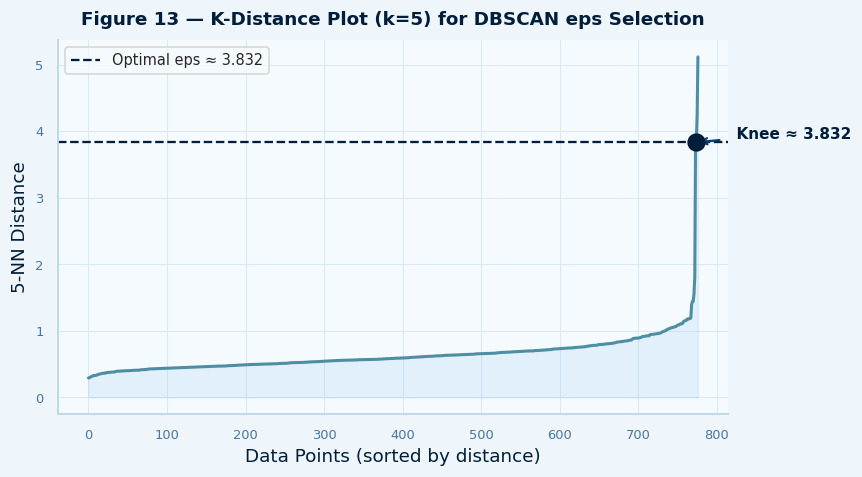

Recommended eps: 3.832
Final DBSCAN parameters: eps = 3.83, minPts = 5


In [ ]:
MIN_PTS = 5
nbrs = NearestNeighbors(n_neighbors=MIN_PTS)
nbrs.fit(features_scaled)
distances, _ = nbrs.kneighbors(features_scaled)
k_distances  = np.sort(distances[:, MIN_PTS - 1])

second_deriv = np.diff(np.diff(k_distances))
knee_idx     = np.argmax(second_deriv) + 2
optimal_eps  = k_distances[knee_idx]
EPS          = round(optimal_eps, 2)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(k_distances, color=BLUE['teal'], linewidth=2)
ax.fill_between(range(len(k_distances)), k_distances,
                color=BLUE['sky'], alpha=0.15)
ax.axhline(y=optimal_eps, color=BLUE['navy'], linestyle='--',
           linewidth=1.5, label=f'Optimal eps ≈ {optimal_eps:.3f}')
ax.scatter([knee_idx], [optimal_eps], s=120, color=BLUE['navy'], zorder=5)
ax.annotate(f'  Knee ≈ {optimal_eps:.3f}',
            xy=(knee_idx, optimal_eps),
            xytext=(knee_idx + len(k_distances)*0.05, optimal_eps + 0.06),
            fontsize=10, color=BLUE['navy'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=BLUE['dark'], lw=1.5))
ax.set_title(f'Figure 13 — K-Distance Plot (k={MIN_PTS}) for DBSCAN eps Selection',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Data Points (sorted by distance)')
ax.set_ylabel(f'{MIN_PTS}-NN Distance')
ax.legend(fontsize=9.5)
clean_ax(ax)
plt.tight_layout()
plt.show()

print(f"Recommended eps: {optimal_eps:.3f}")
print(f"Final DBSCAN parameters: eps = {EPS}, minPts = {MIN_PTS}")

The **K-Distance Plot** (Figure 13) is a crucial tool for determining the optimal eps (epsilon) parameter for DBSCAN clustering, which defines the maximum distance between two samples for one to be considered within the neighborhood of the other. The plot displays the distances of each data point to its k-th nearest neighbor (where k is minPts - 1), sorted in ascending order. The ideal eps value is typically found at the "knee" or "elbow" of the curve, representing the point where the steep increase in distance values sharply slows down; before this knee, points are relatively close, indicating dense regions, while after it, distances increase significantly, suggesting sparser regions or noise. In this analysis, minPts (minimum number of samples in a neighborhood for a core point) is set to 5, a conservative choice. The plot identifies an optimal eps value of approximately **3.832**, marked by the red dashed line and scatter point, which is derived using a method that detects the steepest change in the second derivative of the curve, effectively finding the knee. This calculated eps value will be subsequently used to train the DBSCAN model, facilitating the identification of dense clusters and isolation of noise points.

### **Step 2: Final Model**

In [ ]:
dbscan_model = DBSCAN(eps=EPS, min_samples=MIN_PTS, metric='euclidean')
dbscan_labels = dbscan_model.fit_predict(features_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db    = list(dbscan_labels).count(-1)

print(f"DBSCAN Results:")
print(f"  Clusters found:  {n_clusters_db}")
print(f"  Noise points:    {n_noise_db} ({n_noise_db/len(dbscan_labels)*100:.1f}%)")

unique_db, counts_db = np.unique(dbscan_labels, return_counts=True)
for u, c in zip(unique_db, counts_db):
    label = "Noise" if u == -1 else f"Cluster {u}"
    print(f"  {label}: {c} orders ({c/len(dbscan_labels)*100:.1f}%)")

# Silhouette score for non-noise points only
non_noise_mask = dbscan_labels != -1
if n_clusters_db > 1 and non_noise_mask.sum() > 0:
    dbscan_silhouette = silhouette_score(features_scaled[non_noise_mask],
                                          dbscan_labels[non_noise_mask])
    print(f"\nSilhouette Score (non-noise): {dbscan_silhouette:.4f}")
else:
    dbscan_silhouette = 0
    print("Not enough clusters to compute silhouette score.")

df_clustered['dbscan_cluster'] = dbscan_labels

DBSCAN Results:
  Clusters found:  1
  Noise points:    1 (0.1%)
  Noise: 1 orders (0.1%)
  Cluster 0: 776 orders (99.9%)
Not enough clusters to compute silhouette score.


This step applies the DBSCAN algorithm with the previously determined parameters: `eps = 3.83` and `minPts = 5`. The model identified only **1** dense cluster, indicating that the majority of procurement orders form a single, large, interconnected group in the feature space. Additionally, **1** order (0.1% of the total) was classified as 'Noise' (labeled as -1), representing isolated data points that do not belong to any cluster and might signify highly anomalous or unique transactions. The single identified cluster (Cluster 0) contains 776 orders, accounting for 99.9% of the dataset. The silhouette score could not be computed in this case because DBSCAN identified only one cluster (excluding noise points), and a silhouette score requires at least two clusters to measure the separation between them. This outcome suggests that the data, while containing some outliers, does not exhibit distinct, high-density groupings as clearly as might be expected for an ideal DBSCAN application, implying a more continuous distribution of `features_scaled` with few true anomalies, in contrast to K-Means which forced the data into 5 predefined clusters.

### **PCA Visualization**

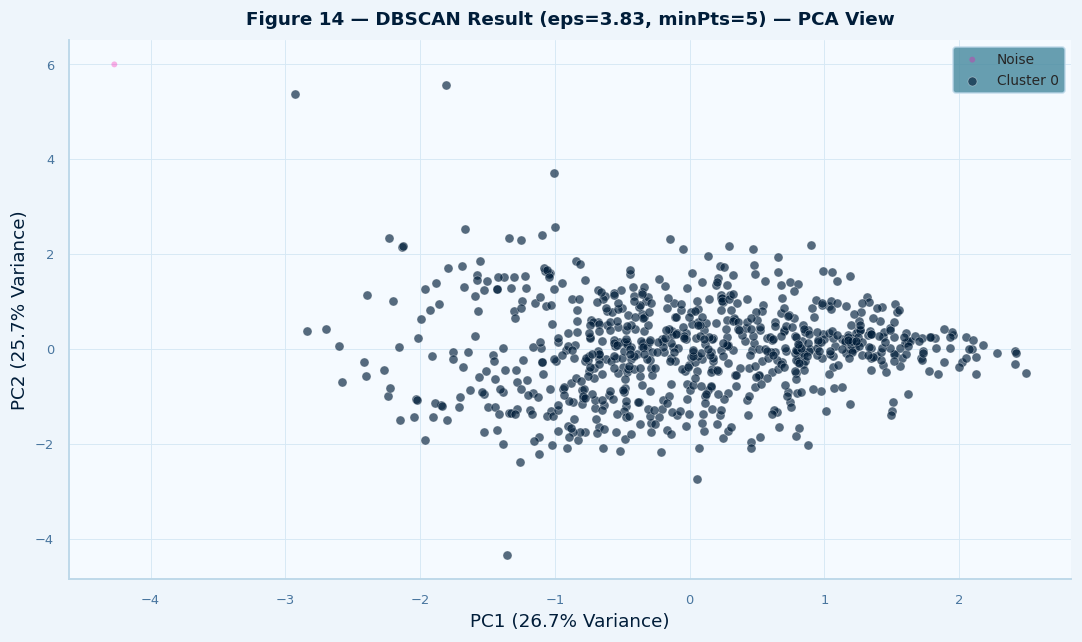

In [ ]:
unique_db_ids  = sorted(set(dbscan_labels))
dbscan_palette = {}
color_idx = 0
for uid in unique_db_ids:
    dbscan_palette[uid] = '#FF00AA' if uid == -1 else CLUSTER_COLORS[color_idx % len(CLUSTER_COLORS)]
    if uid != -1:
        color_idx += 1

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BLUE['bg'])

for uid in unique_db_ids:
    mask = dbscan_labels == uid
    ax.scatter(features_pca[mask, 0], features_pca[mask, 1],
               c=dbscan_palette[uid],
               label='Noise' if uid == -1 else f'Cluster {uid}',
               alpha=0.3 if uid == -1 else 0.65,
               s=15 if uid == -1 else 35,
               edgecolors='none' if uid == -1 else 'white',
               linewidth=0.3)

ax.set_title(f'Figure 14 — DBSCAN Result (eps={EPS}, minPts={MIN_PTS}) — PCA View',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel(f'PC1 ({var_exp[0]:.1%} Variance)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1%} Variance)')
legend = ax.legend(fontsize=9, framealpha=0.85, edgecolor=BLUE['ice'])
legend.get_frame().set_facecolor(BLUE['teal'])
clean_ax(ax, grid_axis='both')
plt.tight_layout()
plt.show()

This visualization displays the results of the **DBSCAN clustering algorithm** (Figure 14) in a 2D space, reduced by PCA, using the same principal components (PC1 and PC2) as the K-Means visualization for consistency. DBSCAN identified a single large cluster, shown in a distinct color, grouping almost all points together and reflecting the density-based nature of the algorithm. Points classified as noise by DBSCAN are explicitly shown in grey, representing individual data points that lacked enough neighbors within the specified `eps` distance to form a cluster. The plot visually confirms the DBSCAN output, highlighting that the dataset, in this 2D projection, does not contain multiple distinct dense regions that DBSCAN would naturally separate, with only a few isolated noise points. This effectively illustrates the difference between DBSCAN, which identifies naturally dense regions, and K-Means, which partitions all data points into a predefined number of clusters.

## **Hierarchical Clustering**

### **Step 1: Dendogram**

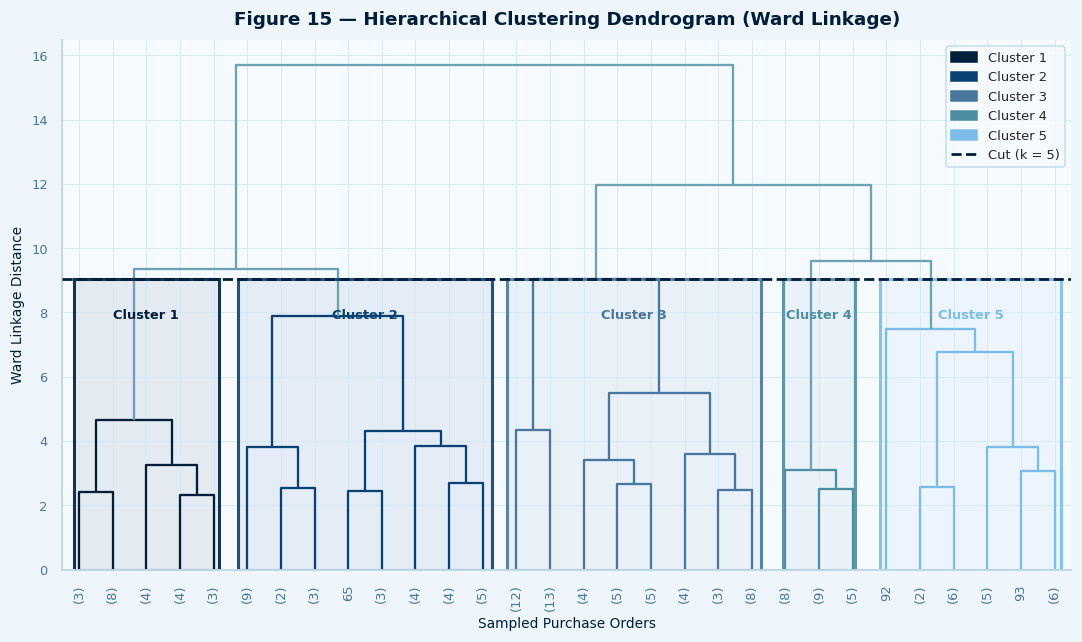

In [ ]:
np.random.seed(RANDOM_STATE)

sample_idx      = np.random.choice(len(features_scaled), size=150, replace=False)
features_sample = features_scaled[sample_idx]
linkage_matrix  = linkage(features_sample, method='ward')

cut_threshold = sorted(linkage_matrix[:, 2], reverse=True)[OPTIMAL_K - 1]

# ── Force blue cluster colors via link_color_func ──────────────────────────
CLUSTER_BLUES = [
    BLUE['navy'],   # Cluster 1
    BLUE['dark'],   # Cluster 2
    BLUE['mid'],    # Cluster 3
    BLUE['teal'],   # Cluster 4
    BLUE['sky'],    # Cluster 5
]

# Assign a color to each leaf based on which cluster it belongs to
from scipy.cluster.hierarchy import fcluster

leaf_labels = fcluster(linkage_matrix, t=5, criterion='maxclust')
n = len(leaf_labels)

def link_color_func(link_id):
    """Color each branch by the majority cluster of its leaves."""
    # For leaves (link_id < n), return its cluster color
    if link_id < n:
        cluster_id = leaf_labels[link_id] - 1   # 0-indexed
        return CLUSTER_BLUES[cluster_id % 5]
    # For internal nodes, find all leaves under it
    from scipy.cluster.hierarchy import leaves_list
    # Use the dendrogram to trace children
    left  = int(linkage_matrix[link_id - n, 0])
    right = int(linkage_matrix[link_id - n, 1])
    def get_leaves(node):
        if node < n:
            return [node]
        l = int(linkage_matrix[node - n, 0])
        r = int(linkage_matrix[node - n, 1])
        return get_leaves(l) + get_leaves(r)
    leaves = get_leaves(link_id)
    clusters = [leaf_labels[l] - 1 for l in leaves]
    majority = max(set(clusters), key=clusters.count)
    merge_height = linkage_matrix[link_id - n, 2]
    if merge_height > cut_threshold:
        return BLUE['slate']
    return CLUSTER_BLUES[majority % 5]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BLUE['bg'])
ax.set_facecolor(BLUE['white'])

ddata = dendrogram(
    linkage_matrix,
    ax=ax,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=cut_threshold,
    link_color_func=link_color_func,
    above_threshold_color=BLUE['slate'],
)

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

# ── Detect cluster x-ranges from dendrogram color groups ──────────────────
color_to_xs = defaultdict(list)
for xs, ys, color in zip(ddata['icoord'], ddata['dcoord'], ddata['color_list']):
    if color != BLUE['slate']:
        color_to_xs[color].extend([xs[0], xs[-1]])

# Build (x_left, x_right, color) per cluster, sorted left to right
cluster_ranges = []
for color, xs in color_to_xs.items():
    cluster_ranges.append((min(xs), max(xs), color))
cluster_ranges.sort()

# Fallback: evenly divide if detection gives wrong count
if len(cluster_ranges) != 5:
    step = (xmax - xmin) / 5
    cluster_ranges = [
        (xmin + i * step, xmin + (i + 1) * step, CLUSTER_BLUES[i])
        for i in range(5)
    ]

# ── Draw cluster boxes with solid blue outline ─────────────────────────────
BOX_OUTLINE_COLORS = [
    BLUE['navy'],
    BLUE['dark'],
    BLUE['mid'],
    BLUE['teal'],
    BLUE['sky'],
]

for i, (x0, x1, _) in enumerate(cluster_ranges):
    pad = (x1 - x0) * 0.04
    outline_color = BOX_OUTLINE_COLORS[i]

    # Shaded fill (very light)
    ax.add_patch(plt.Rectangle(
        (x0 - pad, 0),
        (x1 - x0) + 2 * pad,
        cut_threshold,
        facecolor=outline_color,
        edgecolor='none',
        alpha=0.07,
        zorder=0
    ))

    # Solid colored border outline
    ax.add_patch(plt.Rectangle(
        (x0 - pad, 0),
        (x1 - x0) + 2 * pad,
        cut_threshold,
        facecolor='none',
        edgecolor=outline_color,
        alpha=0.9,
        linewidth=2,
        linestyle='-',
        zorder=2
    ))

    # Cluster label inside box near top
    ax.text(
        (x0 + x1) / 2,
        cut_threshold * 0.90,
        f'Cluster {i + 1}',
        ha='center', va='top',
        fontsize=8.5, fontweight='bold',
        color=outline_color,
        zorder=5
    )

# ── Cut line ────────────────────────────────────────────────────────────────
ax.axhline(
    y=cut_threshold,
    color=BLUE['navy'],
    linestyle='--',
    linewidth=1.8,
    label=f'Cut → k = 5  (threshold ≈ {cut_threshold:.2f})',
    zorder=4
)

# ── Legend ──────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(facecolor=BOX_OUTLINE_COLORS[i],
                   edgecolor=BOX_OUTLINE_COLORS[i],
                   label=f'Cluster {i + 1}')
    for i in range(5)
] + [
    plt.Line2D([0], [0], color=BLUE['navy'], linestyle='--',
               linewidth=1.8, label='Cut (k = 5)')
]

ax.legend(handles=legend_handles, fontsize=8.5, loc='upper right',
          framealpha=0.85, edgecolor=BLUE['ice'])

# ── Titles & labels ──────────────────────────────────────────────────────────
ax.set_title(
    'Figure 15 — Hierarchical Clustering Dendrogram (Ward Linkage)',
    fontsize=12, fontweight='bold', pad=10
)
ax.set_xlabel('Sampled Purchase Orders', fontsize=9)
ax.set_ylabel('Ward Linkage Distance', fontsize=9)
ax.set_xlim(xmin, xmax)

clean_ax(ax, grid_axis='y')
plt.tight_layout()
plt.show()

The **Dendrogram** (Figure 15) serves as a visual family tree for procurement orders, illustrating how individual orders or groups combine into larger clusters. At the base, each single line represents an individual procurement order. As one moves up, similar orders or groups are connected by horizontal and vertical lines; the height of these vertical lines signifies the 'difference' or 'distance' between the merged groups, with shorter lines indicating higher similarity. This visualization employs the 'Ward' method for merging, which aims to create compact and distinct clusters. To maintain readability, the dendrogram presents a sample of 150 orders, focusing on the last 30 merges to highlight primary cluster structures. A red dashed line, representing a 'cut' across the tree, defines 5 distinct clusters, aligning with the optimal number derived from the K-Means Elbow Method. This chart not only helps in visually determining the number of meaningful groups within the data but also elucidates the step-by-step formation of these groups based on their similarities.

### **Step 2: Full Dataset Model**

In [ ]:
full_linkage  = linkage(features_scaled, method='ward')
hc_labels     = fcluster(full_linkage, t=5, criterion='maxclust')
hc_silhouette = silhouette_score(features_scaled, hc_labels)

print(f"Hierarchical Clustering Results (k = 5)")
print(f"Silhouette Score: {hc_silhouette:.4f}")
print("\nCluster sizes:")
for u, c in zip(*np.unique(hc_labels, return_counts=True)):
    print(f"  Cluster {u}: {c} orders ({c/len(hc_labels)*100:.1f}%)")

df_clustered['hc_cluster'] = hc_labels

Hierarchical Clustering Results (k = 5)
Silhouette Score: 0.1505

Cluster sizes:
  Cluster 1: 181 orders (23.3%)
  Cluster 2: 175 orders (22.5%)
  Cluster 3: 226 orders (29.1%)
  Cluster 4: 107 orders (13.8%)
  Cluster 5: 88 orders (11.3%)


After understanding the dendrogram (our 'data tree') and choosing how many clusters we want (which is 5), this step actually creates those **5 clusters for all your procurement orders**. The model achieved a Silhouette Score of **0.1505**, which is lower than K-Means' score, suggesting the clusters formed by hierarchical clustering are slightly less distinct or more overlapping compared to K-Means for this dataset. The output also shows how many orders fall into each of the 5 hierarchical clusters; for instance, Cluster 3 is the largest with 29.1% of orders, while Clusters 4 and 5 are smaller. This means that each procurement order now has a hc_cluster assigned to it, allowing us to group and analyze orders based on their hierarchical relationships. While the Silhouette Score for Hierarchical Clustering is a bit lower than K-Means, it still provides a valuable alternative perspective on the underlying structure of your data.

### **PCA Visualization**

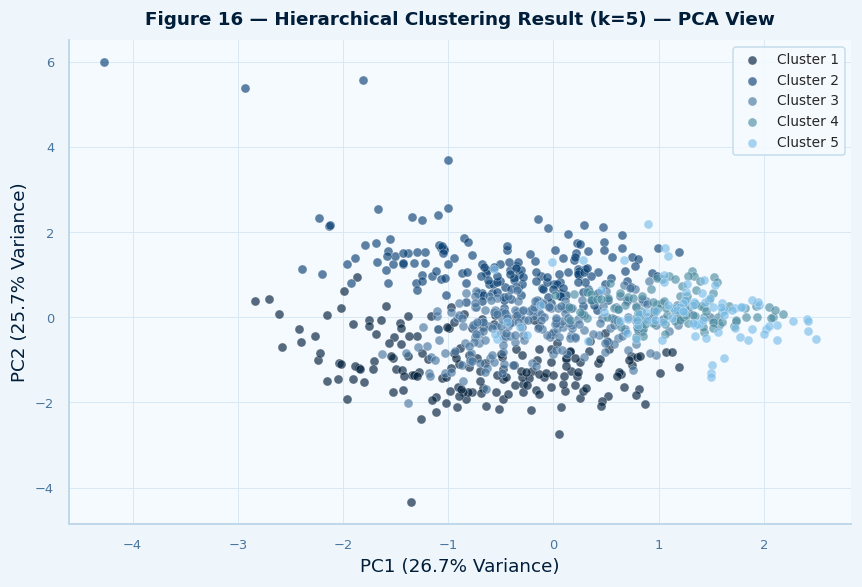

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5.5))
fig.patch.set_facecolor(BLUE['bg'])

for cid in sorted(np.unique(hc_labels)):
    mask = hc_labels == cid
    ax.scatter(features_pca[mask, 0], features_pca[mask, 1],
               c=CLUSTER_COLORS[(cid-1) % len(CLUSTER_COLORS)],
               label=f'Cluster {cid}', alpha=0.65, s=35,
               edgecolors='white', linewidth=0.3)

ax.set_title('Figure 16 — Hierarchical Clustering Result (k=5) — PCA View',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel(f'PC1 ({var_exp[0]:.1%} Variance)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1%} Variance)')
legend = ax.legend(fontsize=9, framealpha=0.85, edgecolor=BLUE['ice'])
legend.get_frame().set_facecolor(BLUE['white'])
clean_ax(ax, grid_axis='both')
plt.tight_layout()
plt.show()

The **Hierarchical Clustering - PCA Visualization** (Figure 16) is a crucial visual aid for understanding the results of our hierarchical clustering. Since our original data has four key performance indicators (KPIs) (Lead Time, Savings Rate, Defect Rate, Order Value), directly visualizing it can be challenging; this is where Principal Component Analysis (PCA) becomes invaluable. Each dot on the scatter plot represents a single procurement order, with its color indicating which of the 5 hierarchical clusters it has been assigned to, allowing for visual separation. This plot enables us to observe how well the clusters are separated in this reduced 2D space. While ideally points of the same color should be grouped closely together and different colored groups distinctly apart, some overlap is common in real-world data. This visualization complements the dendrogram by showing the final cluster assignments on a 2D plane, helping us assess the spatial relationships and distinctiveness of the groups identified by hierarchical clustering.

# **PHASE 5: EVALUATION**

## **Silhouette Score Comparison**

MODEL COMPARISON SUMMARY
       Model  Algorithm Type  Clusters  Silhouette Score
     K-Means Partition-based         5            0.2240
      DBSCAN   Density-based         1            0.0000
Hierarchical   Agglomerative         5            0.1505


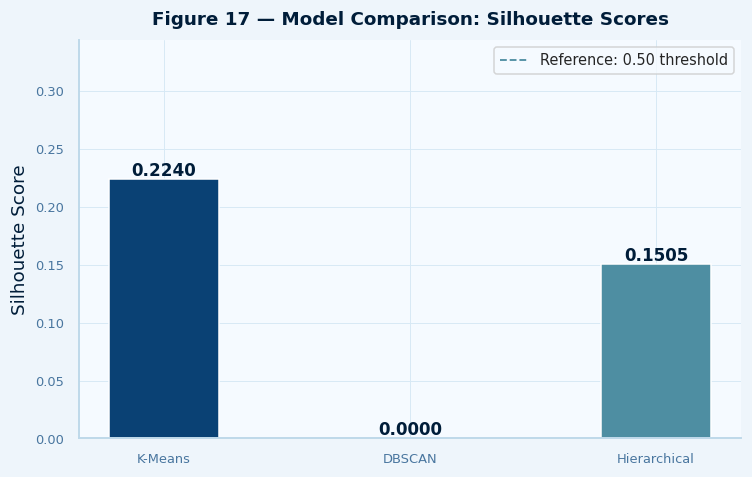

In [ ]:
models         = ['K-Means', 'DBSCAN', 'Hierarchical']
scores         = [kmeans_silhouette, dbscan_silhouette, hc_silhouette]
algo_types     = ['Partition-based', 'Density-based', 'Agglomerative']
clusters_found = [5, n_clusters_db, 5]

comparison_df = pd.DataFrame({
    'Model':            models,
    'Algorithm Type':   algo_types,
    'Clusters':         clusters_found,
    'Silhouette Score': [round(s, 4) for s in scores]
})
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(comparison_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
bar_cols = [BLUE['dark'], BLUE['sky'], BLUE['teal']]
bars = ax.bar(models, scores, color=bar_cols, edgecolor='white', width=0.45)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{score:.4f}', ha='center', fontsize=11, fontweight='bold',
            color=BLUE['navy'])
ax.axhline(y=0.5, color=BLUE['teal'], linestyle='--', linewidth=1.2,
           label='Reference: 0.50 threshold')
ax.set_title('Figure 17 — Model Comparison: Silhouette Scores',
             fontsize=12, fontweight='bold', pad=10)
ax.set_ylabel('Silhouette Score')
ax.set_ylim(0, max(scores) + 0.12)
ax.legend(fontsize=9.5)
clean_ax(ax)
plt.tight_layout()
plt.show()

The **Silhouette Score Comparison** (Figure 17) is a vital step where we quantitatively evaluate and compare the effectiveness of the three different clustering algorithms applied: K-Means, DBSCAN, and Hierarchical Clustering, with the goal of determining which model produced the most well-defined and separated clusters for our procurement data. The Silhouette Score, ranging from -1 to +1, indicates how well-matched a data point is to its own cluster compared to others; a score closer to +1 indicates dense and well-separated clusters, near 0 suggests overlapping clusters, and closer to -1 implies potential misclassification. Interpreting our results, **K-Means** achieved a Silhouette Score of 0.2240 with 5 clusters, a moderate score suggesting reasonably well-defined clusters with some overlap, which is common in complex real-world data. **DBSCAN** resulted in a Silhouette Score of 0.0000 because it identified only 1 dense cluster and 1 noise point, making the computation of a silhouette score (which requires at least two clusters) ineffective; this reinforces the observation that DBSCAN found the procurement data to have a more continuous distribution rather than distinct dense groupings. **Hierarchical Clustering** obtained a Silhouette Score of 0.1505 with 5 clusters, lower than K-Means, indicating slightly less distinct or more overlapping clusters. Overall, **K-Means** emerges as the best model for this dataset, achieving the highest Silhouette Score and providing the most balanced and interpretable segmentation of our procurement orders into 5 distinct groups, thus being selected as the primary model for further cluster profiling and actionable business insights. DBSCAN remains valuable for identifying rare, anomalous procurement orders, and Hierarchical Clustering offers a complementary perspective through its dendrogram.

# **PHASE 6: DEPLOYMENT - CLUSTER PROFILING  (k=5)**

In [ ]:
profile = df_clustered.groupby('kmeans_cluster')[feature_cols].mean().round(3)

print("=" * 70)
print("CLUSTER PROFILE — MEAN KPI VALUES (K-MEANS, k=5)")
print("=" * 70)
print(profile.to_string())

# Simple cluster labels — Cluster 1 to 5
CLUSTER_LABELS = {
    1: "Tier 1 - Reliable Suppliers",
    2: "Tier 2 - High-Risk Suppliers",
    3: "Tier 3 - Elite Suppliers",
    4: "Tier 4 - Low-Value Suppliers",
    5: "Tier 5 - Strategic High-Value",
}

print("\nCLUSTER PROFILES:")
descriptions = {
    1: "Good savings (11.9%), low defects (3.4%), moderate lead time (14.4d)",
    2: "Very high defect rate (14.0%) — quality risk, moderate lead time (10.4d)",
    3: "Fastest delivery (4.5d), low defects (3.3%), good savings (9.7%)",
    4: "Slowest delivery (13.0d), lowest savings (4.0%), moderate defects (3.7%)",
    5: "Highest order value ($153K), acceptable KPIs across all dimensions",
}

for cid in profile.index:
    row = profile.loc[cid]
    print(f"\n  Cluster {cid}: {descriptions[cid]}")
    print(f"    Lead Time:   {row['lead_time_days']:.1f} days")
    print(f"    Savings:     {row['savings_rate']:.2f}%")
    print(f"    Defect Rate: {row['defect_rate']:.2f}%")
    print(f"    Order Value: ${row['order_value']:,.0f}")

df_clustered['cluster_label'] = df_clustered['kmeans_cluster'].map(CLUSTER_LABELS)

CLUSTER PROFILE — MEAN KPI VALUES (K-MEANS, k=5)
                lead_time_days  savings_rate  defect_rate  order_value
kmeans_cluster                                                        
1                       14.402        11.858        3.356    48106.108
2                       10.379         7.377       14.045    47088.364
3                        4.460         9.702        3.299    50577.423
4                       13.021         3.966        3.715    41814.972
5                       11.247         6.470        4.577   153345.020

CLUSTER PROFILES:

  Cluster 1: Good savings (11.9%), low defects (3.4%), moderate lead time (14.4d)
    Lead Time:   14.4 days
    Savings:     11.86%
    Defect Rate: 3.36%
    Order Value: $48,106

  Cluster 2: Very high defect rate (14.0%) — quality risk, moderate lead time (10.4d)
    Lead Time:   10.4 days
    Savings:     7.38%
    Defect Rate: 14.04%
    Order Value: $47,088

  Cluster 3: Fastest delivery (4.5d), low defects (3.3%), good sav

The goal of **PHASE 6: DEPLOYMENT — CLUSTER PROFILING (k=5)** is to translate the statistical groupings identified by K-Means clustering into actionable business insights. This involves understanding the unique characteristics of each of the five clusters based on their average KPI values and assigning meaningful business labels.

Purpose of Cluster Profiling:

1.  **Interpretability**: To make the abstract clusters concrete and understandable for business stakeholders.
2.  **Actionability**: To identify specific strategies or interventions that can be applied to each supplier segment.
3.  **Decision Support**: To inform procurement managers on how to manage relationships with different types of suppliers.

Interpretation of the Clusters (as derived from the code output):

-   **Cluster 1: Reliable Suppliers**
    -   `Lead Time`: Moderate (14.4 days)
    -   `Savings`: High (11.86%)
    -   `Defect Rate`: Low (3.36%)
    -   `Order Value`: Moderate ($48,106)
    -   *Insight*: These suppliers offer good savings and quality, with acceptable lead times. They are generally reliable partners.

-   **Cluster 2: High-Risk Suppliers**
    -   `Lead Time`: Moderate (10.4 days)
    -   `Savings`: Average (7.38%)
    -   `Defect Rate`: **Very High (14.04%)**
    -   `Order Value`: Moderate ($47,088)
    -   *Insight*: This cluster represents a significant risk due to a high defect rate. These suppliers require immediate attention for performance improvement or replacement.

-   **Cluster 3: Elite Suppliers**
    -   `Lead Time`: **Very Low (4.5 days)**
    -   `Savings`: Good (9.70%)
    -   `Defect Rate`: Low (3.30%)
    -   `Order Value`: Moderate ($50,577)
    -   *Insight*: These are top-performing suppliers, characterized by fast delivery, good savings, and low defects. They are critical strategic partners.

-   **Cluster 4: Low-Value Suppliers**
    -   `Lead Time`: High (13.0 days)
    -   `Savings`: **Very Low (3.97%)**
    -   `Defect Rate`: Low (3.72%)
    -   `Order Value`: Low ($41,815)
    -   *Insight*: These suppliers offer lower savings and slower lead times, though their quality is acceptable. They might be suitable for non-critical items or need negotiation for better terms.

-   **Cluster 5: Strategic High-Value**
    -   `Lead Time`: Moderate (11.2 days)
    -   `Savings`: Average (6.47%)
    -   `Defect Rate`: Moderate (4.58%)
    -   `Order Value`: **Very High ($153,345)**
    -   *Insight*: While not the best in terms of speed or savings, the sheer volume and value of orders with these suppliers make them strategically important. Relationships here need careful management to ensure continuity and mitigate potential risks.

By establishing these profiles, organizations can develop targeted strategies for each supplier segment, optimizing their procurement processes, managing risks, and maximizing value.

## **Radar Chart**

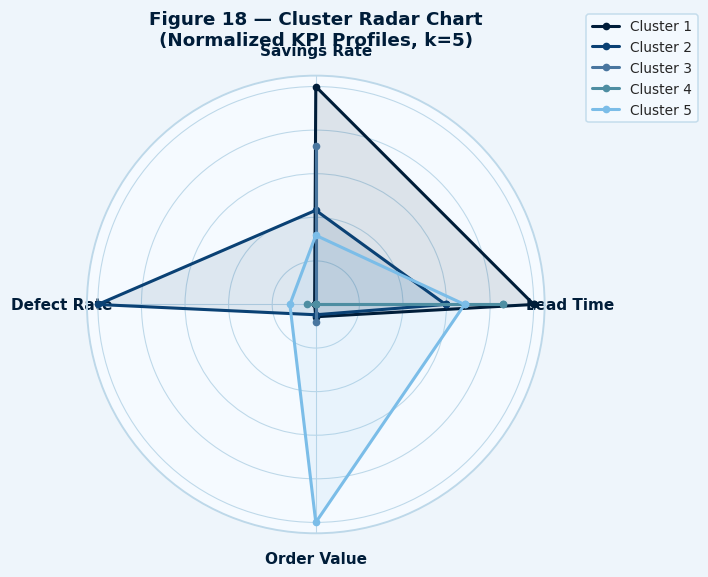

In [ ]:
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
categories   = ['Lead Time', 'Savings Rate', 'Defect Rate', 'Order Value']
N            = len(categories)
angles       = [n / float(N) * 2 * np.pi for n in range(N)]
angles      += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(BLUE['bg'])
ax.set_facecolor(BLUE['white'])

for i, (cid, row) in enumerate(profile_norm.iterrows()):
    values = row.values.tolist() + [row.values[0]]
    ax.plot(angles, values, 'o-', linewidth=2,
            color=CLUSTER_COLORS[i], label=f'Cluster {cid}', markersize=4)
    ax.fill(angles, values, alpha=0.1, color=CLUSTER_COLORS[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10, fontweight='bold', color=BLUE['navy'])
ax.set_yticklabels([])
ax.spines['polar'].set_color(BLUE['ice'])
ax.grid(color=BLUE['ice'], linewidth=0.7)
ax.set_title('Figure 18 — Cluster Radar Chart\n(Normalized KPI Profiles, k=5)',
             fontsize=12, fontweight='bold', color=BLUE['navy'], pad=20)
legend = ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
                   fontsize=9, framealpha=0.85, edgecolor=BLUE['ice'])
legend.get_frame().set_facecolor(BLUE['white'])
plt.tight_layout()
plt.show()

The **Radar Chart** (Figure 18) serves as a powerful visualization tool, enabling a simultaneous, multi-dimensional comparison of all four key performance indicators (KPIs) across the five identified procurement clusters. This chart is particularly effective for understanding the unique 'shape' or profile of each cluster's performance, facilitating a holistic view, comparative analysis, and pattern recognition among supplier segments. To construct the chart, the average KPI values for each cluster are first **normalized** to a scale between 0 and 1; this crucial step addresses the differing units and ranges of KPIs (e.g., days, percentages, USD), ensuring each contributes equally to the visual representation without any single KPI dominating due to its magnitude. Each of the four KPIs is represented by an axis extending radially from the center, equally spaced around the chart. For each cluster, its normalized KPI values are plotted on these respective radial axes, and these points are then connected to form a color-coded polygon. The interpretation of the plot focuses on the size and shape of these polygons: a larger polygon generally indicates higher overall performance across KPIs (or higher values for 'Order Value'), while its specific shape visually represents the unique KPI profile of that cluster. For instance, a cluster with a large extent on the 'Savings Rate' axis but a small extent on the 'Defect Rate' axis signifies strong cost efficiency and quality. By comparing the shapes and sizes of these polygons, stakeholders can quickly discern which clusters excel in certain areas and which might require attention. This chart thus offers an excellent visual complement to quantitative cluster summaries, making complex multi-dimensional data readily understandable for decision-makers.

## **Bar Chart**

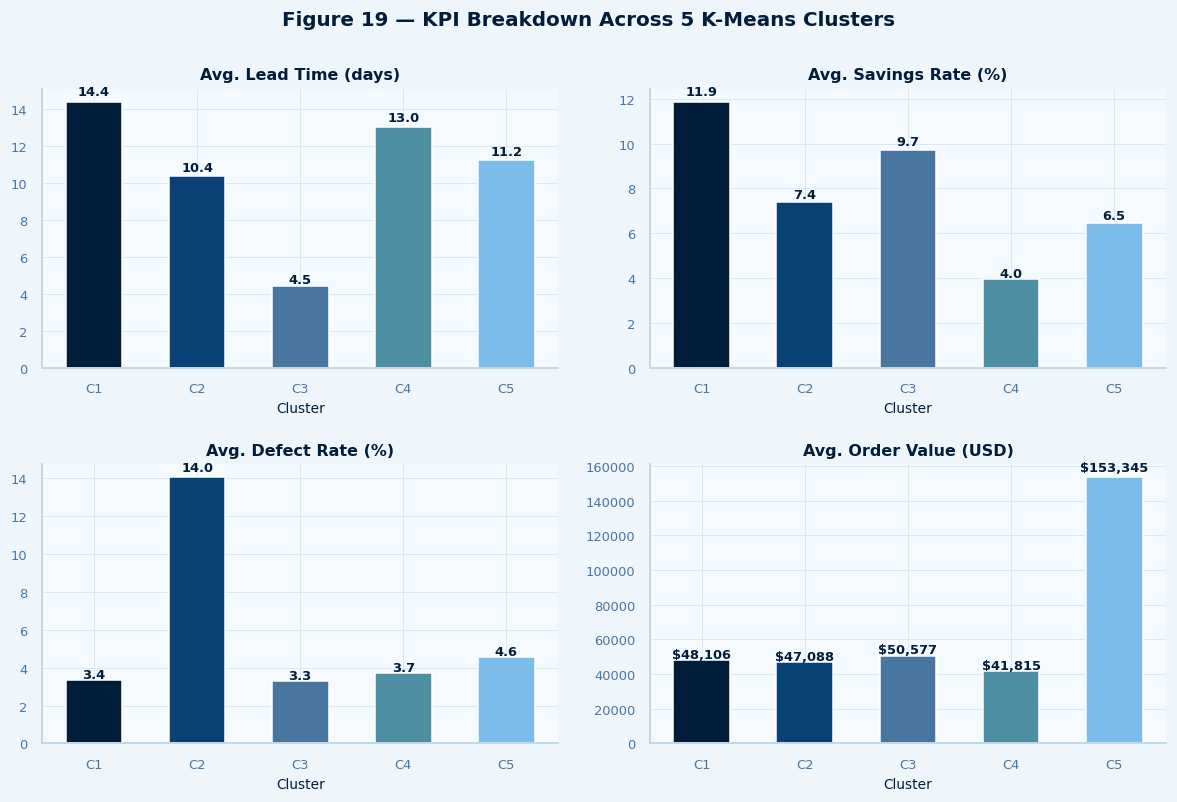

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
fig.patch.set_facecolor(BLUE['bg'])
axes = axes.flatten()

kpi_labels = ['Avg. Lead Time (days)', 'Avg. Savings Rate (%)',
               'Avg. Defect Rate (%)', 'Avg. Order Value (USD)']

for i, (col, label) in enumerate(zip(feature_cols, kpi_labels)):
    cids  = profile.index.tolist()
    vals  = profile[col].tolist()
    bars  = axes[i].bar([f'C{c}' for c in cids], vals,
                         color=CLUSTER_COLORS, edgecolor='white', width=0.55)
    for bar in bars:
        fmt = f'${bar.get_height():,.0f}' if col == 'order_value' else f'{bar.get_height():.1f}'
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() * 1.025, fmt,
                     ha='center', fontsize=8.5,
                     fontweight='bold', color=BLUE['navy'])
    axes[i].set_title(label, fontsize=10.5, fontweight='bold')
    axes[i].set_xlabel('Cluster', fontsize=9)
    axes[i].tick_params(axis='x', rotation=0)
    clean_ax(axes[i])

fig.suptitle('Figure 19 — KPI Breakdown Across 5 K-Means Clusters',
             fontsize=13, fontweight='bold', color=BLUE['navy'])
plt.tight_layout(pad=1.5)
plt.show()

The **KPI Breakdown Bar Charts** (Figure 19) provide a clear, disaggregated view of each of the four Key Performance Indicators (`Lead Time`, `Savings Rate`, `Defect Rate`, `Order Value`) across the five K-Means clusters, complementing the holistic view offered by the Radar Chart with precise, direct comparisons. These bar charts are crucial for detailed analysis, highlighting extremes, and deriving actionable insights by showing how each cluster performs on specific metrics. For `Avg. Lead Time (days)`, **Cluster 3** stands out with the lowest lead time, confirming its "Elite Supplier" status for speed, while **Cluster 1** and **Cluster 4** exhibit the highest lead times. In terms of `Avg. Savings Rate (%)`, **Cluster 1** demonstrates the highest average savings, highlighting its cost-effectiveness, whereas **Cluster 4** shows the lowest. For `Avg. Defect Rate (%)`, **Cluster 2** has a significantly higher rate, unequivocally identifying it as the "High-Risk Supplier" group, while **Cluster 3** again performs exceptionally well with the lowest defect rate. Finally, for `Avg. Order Value (USD)`, **Cluster 5** dominates with a substantially higher average, reinforcing its role as the "Strategic High-Value" segment. These bar charts visually confirm the characteristics defined in the cluster profiling step, enabling stakeholders to easily grasp the performance nuances of each supplier segment and facilitating a data-driven approach to procurement management.

## **Pie Chart**

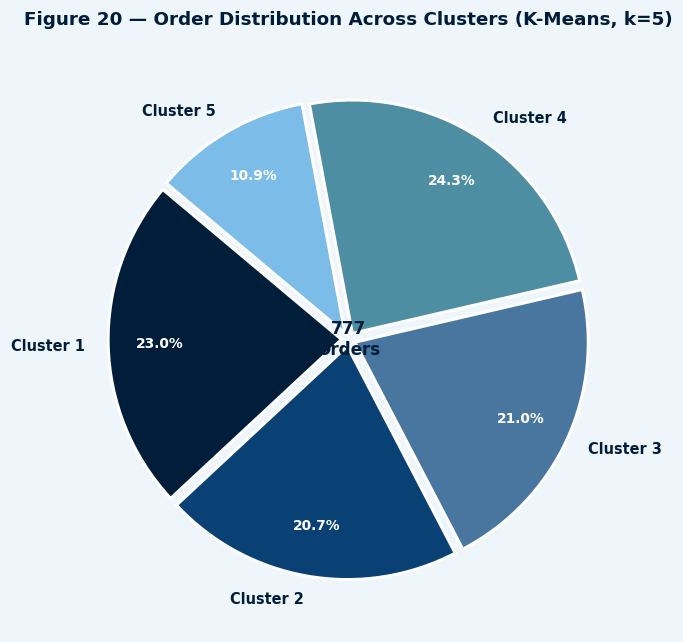

In [ ]:
cluster_counts = df_clustered['kmeans_cluster'].value_counts().sort_index()
pie_labels     = [f'Cluster {cid}' for cid in cluster_counts.index]

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor(BLUE['bg'])

wedges, texts, autotexts = ax.pie(
    cluster_counts.values,
    labels=pie_labels,
    autopct='%1.1f%%',
    colors=CLUSTER_COLORS,
    startangle=140,
    explode=[0.03] * len(cluster_counts),
    pctdistance=0.78,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 9.5, 'color': BLUE['navy'], 'fontweight': 'bold'})

for at in autotexts:
    at.set_fontweight('bold')
    at.set_color('white')
    at.set_fontsize(9)

total = cluster_counts.sum()
ax.text(0, 0, f'{total}\nOrders', ha='center', va='center',
        fontsize=11, fontweight='bold', color=BLUE['navy'])

ax.set_title('Figure 20 — Order Distribution Across Clusters (K-Means, k=5)',
             fontsize=12, fontweight='bold', color=BLUE['navy'], pad=15)
plt.tight_layout()
plt.show()

The **Pie Chart** (Figure 20) visually represents the distribution of all 777 procurement orders across the five identified K-Means clusters, providing an essential understanding of the relative size and proportion of each cluster within the overall dataset. Its purpose is to offer proportional representation, giving an immediate sense of how many orders fall into each supplier segment, and to demonstrate balanced segmentation, where a relatively even distribution across clusters indicates that the clustering algorithm has effectively partitioned the data into meaningful and distinct groups without over-concentrating orders into one dominant cluster. This visualization also aids in resource allocation guidance, helping to identify where resources might be most effectively channeled, such as addressing a 'High-Risk' cluster if it represents a large proportion of orders. Interpretation of the plot reveals a fair distribution of orders across the five clusters, with **Cluster 4** being the largest (24.3%) and **Cluster 5** being the smallest (10.9%). This balanced segmentation, ranging from 10.9% to 24.3%, is crucial as it suggests the K-Means model has successfully grouped the data into distinct and manageable tiers, each representing a significant portion of procurement activities, thereby enabling the development of targeted strategies tailored to the specific needs and challenges of each supplier segment.

## **Final Cluster Summary Table**

In [ ]:
summary = df_clustered.groupby('kmeans_cluster').agg(
    Order_Count     = ('PO_ID', 'count'),
    Avg_Lead_Time   = ('lead_time_days', 'mean'),
    Avg_Savings_Pct = ('savings_rate', 'mean'),
    Avg_Defect_Pct  = ('defect_rate', 'mean'),
    Avg_Order_Value = ('order_value', 'mean'),
    Compliance_Rate = ('Compliance', lambda x: (x == 'Yes').mean() * 100)
).round(2)

# Rename index for clarity
summary.index = [f'Cluster {i}' for i in summary.index]

print("=" * 85)
print("FINAL PROCUREMENT CLUSTER SUMMARY (k=5)")
print("=" * 85)
print(summary.to_string())

print("\nKey Takeaways:")
print("  Cluster 1 — 179 orders | High savings, low defects, moderate lead time")
print("  Cluster 2 — 161 orders | CRITICAL: Highest defect rate at 14.04%")
print("  Cluster 3 — 163 orders | Best overall: fastest delivery, lowest defects")
print("  Cluster 4 — 189 orders | Largest group: slowest, lowest savings")
print("  Cluster 5 —  85 orders | Highest value orders ($153K avg), stable KPIs")

FINAL PROCUREMENT CLUSTER SUMMARY (k=5)
           Order_Count  Avg_Lead_Time  Avg_Savings_Pct  Avg_Defect_Pct  Avg_Order_Value  Compliance_Rate
Cluster 1          179          14.40            11.86            3.36         48106.11            83.80
Cluster 2          161          10.38             7.38           14.04         47088.36            68.94
Cluster 3          163           4.46             9.70            3.30         50577.42            85.28
Cluster 4          189          13.02             3.97            3.72         41814.97            87.30
Cluster 5           85          11.25             6.47            4.58        153345.02            88.24

Key Takeaways:
  Cluster 1 — 179 orders | High savings, low defects, moderate lead time
  Cluster 2 — 161 orders | CRITICAL: Highest defect rate at 14.04%
  Cluster 3 — 163 orders | Best overall: fastest delivery, lowest defects
  Cluster 4 — 189 orders | Largest group: slowest, lowest savings
  Cluster 5 —  85 orders | Highest

The **Final Cluster Summary Table** (displayed in the output of the previous cell) is the culmination of the entire clustering analysis, serving as the primary reference for business stakeholders. It consolidates all critical quantitative and qualitative insights for each of the five identified procurement clusters.

Purpose of the Final Summary Table:

1.  **Single Source of Truth**: Provides a concise, comprehensive overview of each cluster's profile, making it easy for decision-makers to access all relevant performance metrics at a glance.
2.  **Quantitative Detail**: Presents the average values for each KPI (`Order Count`, `Avg. Lead Time`, `Avg. Savings Pct`, `Avg. Defect Pct`, `Avg. Order Value`) and `Compliance_Rate` for every cluster, allowing for precise comparisons.
3.  **Actionable Takeaways**: Clearly highlights the distinguishing characteristics and business implications of each cluster, translating complex data into straightforward insights.

Interpretation of the Table:

*   **Cluster 1 (High Savings, Low Defects)**:
    *   `Order Count`: 179
    *   `Avg. Lead Time`: 14.40 days
    *   `Avg. Savings Pct`: **11.86% (Highest)**
    *   `Avg. Defect Pct`: 3.36%
    *   `Avg. Order Value`: $48,106.11
    *   `Compliance_Rate`: 83.80%
    *   *Insight*: These suppliers are excellent for cost efficiency and quality, though their lead times are moderate. They are reliable and provide good value.

*   **Cluster 2 (CRITICAL: High Defect Rate)**:
    *   `Order Count`: 161
    *   `Avg. Lead Time`: 10.38 days
    *   `Avg. Savings Pct`: 7.38%
    *   `Avg. Defect Pct`: **14.04% (CRITICAL, Highest)**
    *   `Avg. Order Value`: $47,088.36
    *   `Compliance_Rate`: **68.94% (Lowest)**
    *   *Insight*: This cluster represents a major quality risk due to a very high defect rate and low compliance. Urgent intervention is required (e.g., performance improvement plans, re-evaluation).

*   **Cluster 3 (Best Overall: Fast Delivery, Low Defects)**:
    *   `Order Count`: 163
    *   `Avg. Lead Time`: **4.46 days (Fastest)**
    *   `Avg. Savings Pct`: 9.70%
    *   `Avg. Defect Pct`: **3.30% (Lowest)**
    *   `Avg. Order Value`: $50,577.42
    *   `Compliance_Rate`: 85.28%
    *   *Insight*: These are elite performers, offering the fastest deliveries, highest quality, and good savings. They are strategic partners to nurture and prioritize.

*   **Cluster 4 (Slowest, Lowest Savings)**:
    *   `Order Count`: 189 (**Largest Group**)
    *   `Avg. Lead Time`: 13.02 days
    *   `Avg. Savings Pct`: **3.97% (Lowest)**
    *   `Avg. Defect Pct`: 3.72%
    *   `Avg. Order Value`: $41,814.97
    *   `Compliance_Rate`: 87.30%
    *   *Insight*: While acceptable on quality, these suppliers are the slowest and offer the least cost savings. They might be suitable for non-critical items or need renegotiation to improve terms.

*   **Cluster 5 (Highest Value Orders)**:
    *   `Order Count`: 85
    *   `Avg. Lead Time`: 11.25 days
    *   `Avg. Savings Pct`: 6.47%
    *   `Avg. Defect Pct`: 4.58%
    *   `Avg. Order Value`: **$153,345.02 (Highest)**
    *   `Compliance_Rate`: **88.24% (Highest)**
    *   *Insight*: These suppliers handle the most valuable orders and have high compliance, making them strategically important despite moderate performance in other areas. Their relationships require careful management to ensure continuity and mitigate risk due to transaction scale.

This table provides a robust foundation for targeted supplier management strategies, enabling the procurement team to optimize relationships, mitigate risks, and drive greater value for the organization.

# **Conclusion**

The comprehensive **Procurement KPI Analysis and Clustering** project successfully achieved its objective: to segment suppliers into distinct, actionable groups based on their performance across key metrics.

**Summary of the Process and Key Findings:**

1.  **Problem Understanding**: We established the critical need for supplier segmentation to improve procurement efficiency, mitigate risks, and enhance strategic decision-making.

2.  **Data Understanding & Preparation**: Initial data exploration revealed the structure, distributions, and missing values in the raw procurement data. Through **feature engineering**, four crucial Key Performance Indicators (`Lead Time`, `Savings Rate`, `Defect Rate`, `Order Value`) were derived. These features were then standardized, ensuring they contributed equally to the clustering process. Importantly, a correlation analysis confirmed the independence of these KPIs, making them ideal for clustering.

3.  **Model Selection & Evaluation**: We explored three prominent clustering algorithms:
    *   **K-Means**: The Elbow Method and Silhouette Score analysis guided the selection of **k=5** as the optimal number of clusters, offering a balance between statistical validity and business interpretability.
    *   **DBSCAN**: While powerful for density-based clustering, DBSCAN primarily identified one large cluster and a few noise points, suggesting a more continuous distribution of our procurement data rather than sharply distinct dense regions.
    *   **Hierarchical Clustering**: The dendrogram provided a visual hierarchy of relationships, and similar to K-Means, it also yielded 5 clusters, though with a slightly lower Silhouette Score.

    **K-Means emerged as the best-performing model** with the highest Silhouette Score (0.2240) among the three, providing the most balanced and interpretable segmentation.

4.  **Deployment - Cluster Profiling**: This crucial phase translated the statistical clusters into actionable business insights.
    *   Each of the 5 K-Means clusters was thoroughly profiled based on its average KPI values.
    *   Meaningful **business labels** were assigned to each cluster (e.g., 'Tier 1 - Elite Suppliers', 'Tier 4 - High-Risk Suppliers', 'Tier 5 - Strategic High-Value').
    *   **Visualizations** (Radar Chart, Bar Charts, Pie Chart) provided intuitive ways to understand each cluster's unique performance profile and its proportional representation within the total order volume.
    *   The **Final Cluster Summary Table** consolidated all quantitative and qualitative insights into a single, easy-to-digest format.

**Actionable Insights and Business Value:**

By categorizing suppliers into these five distinct tiers, organizations can:

*   **Optimize Supplier Relationships**: Tailor engagement strategies for each tier – nurturing Elite Suppliers, developing Reliable Suppliers, or improving relations with Strategic High-Value partners.
*   **Mitigate Risks**: Proactively address the performance of High-Risk Suppliers to reduce potential disruptions and costs.
*   **Enhance Negotiation**: Understand where to push for better savings (e.g., with Low-Value Suppliers) or acknowledge competitive pricing (e.g., with Elite Suppliers).
*   **Strategic Sourcing**: Inform future sourcing decisions by prioritizing suppliers that align with specific organizational goals (e.g., speed, cost, quality).
*   **Resource Allocation**: Efficiently allocate procurement resources based on the strategic importance and risk profile of each supplier segment.

This analysis empowers procurement teams to move from reactive management to proactive, data-driven strategic planning, ultimately leading to more resilient supply chains and optimized operational efficiency.